**LOAD**

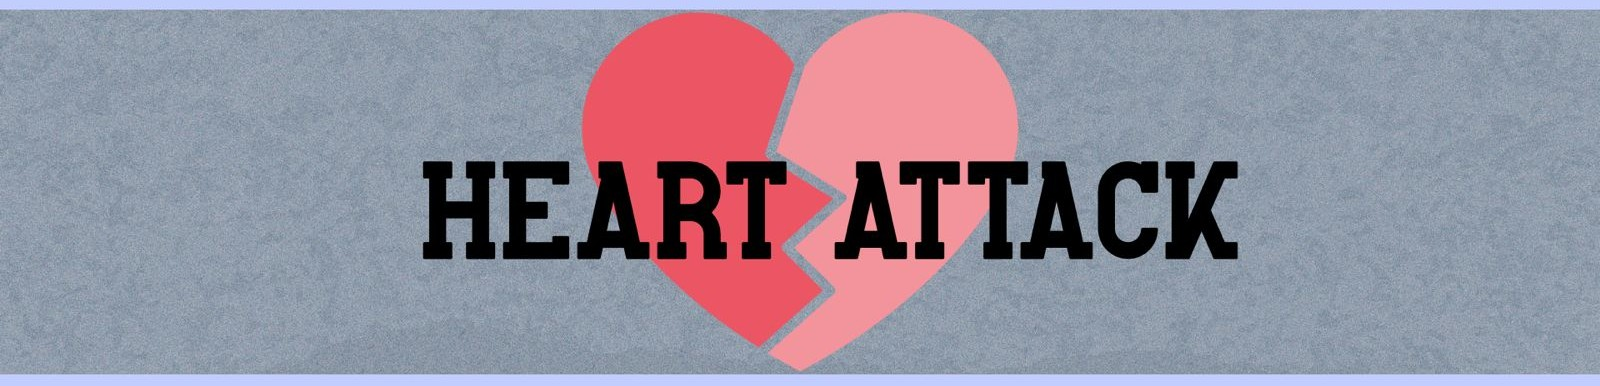

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, recall_score

###### 1. CARGA DE DATOS
Se carga el dataset especificando el delimitador ';' ya que no es un CSV estándar separado por comas.

In [2]:
df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv", sep= ";")

**INSPECT**

In [3]:
df.shape

(5110, 11)

In [4]:
df.index

RangeIndex(start=0, stop=5110, step=1)

In [5]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [7]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### Análisis Exploratorio Univariado
Antes de transformar los datos, revisamos la distribución general de nuestros pacientes, sus condiciones de salud y estilo de vida.

In [8]:
print("DEMOGRAFÍA Y ESTILO DE VIDA")
print("Estado Civil:\n", df['ever_married'].value_counts().to_string())
print("\nTipo de Residencia:\n", df['Residence_type'].value_counts().to_string())
print("\nGénero:\n", df['gender'].value_counts().to_string())
print(f"\nPacientes Jóvenes (15 a 20 años): {df['age'].between(15,20).sum()}")

print("\n\nCONDICIONES DE SALUD")
print("Estado de fumador:\n", df['smoking_status'].value_counts().to_string())
print("\nEnfermedad Cardíaca (0=No, 1=Sí):\n", df['heart_disease'].value_counts().to_string())
print("\nHipertensión (0=No, 1=Sí):\n", df['hypertension'].value_counts().to_string())

print("\n\nÍNDICE DE MASA CORPORAL (BMI)")
print(f"Peso normal (18.5 - 24.9): {df['bmi'].between(18.5, 24.9).sum()} pacientes")
print(f"Sobrepeso (25.0 - 29.9): {df['bmi'].between(25, 29.9).sum()} pacientes")

DEMOGRAFÍA Y ESTILO DE VIDA
Estado Civil:
 ever_married
Yes    3353
No     1757

Tipo de Residencia:
 Residence_type
Urban    2596
Rural    2514

Género:
 gender
Female    2994
Male      2115
Other        1

Pacientes Jóvenes (15 a 20 años): 326


CONDICIONES DE SALUD
Estado de fumador:
 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789

Enfermedad Cardíaca (0=No, 1=Sí):
 heart_disease
0    4834
1     276

Hipertensión (0=No, 1=Sí):
 hypertension
0    4612
1     498


ÍNDICE DE MASA CORPORAL (BMI)
Peso normal (18.5 - 24.9): 1243 pacientes
Sobrepeso (25.0 - 29.9): 1409 pacientes


### **CLEAN**
**Comparación de Estrategias: Data Cleaning y Feature Engineering**.

En esta sección vamos a comparar qué sucede con las métricas del dataset si eliminamos los valores nulos (NaN) de la columna `bmi` frente a si los imputamos (rellenamos) usando la mediana.
Este paso es crucial porque la variable objetivo `stroke` está fuertemente desbalanceada.

In [9]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [10]:
df_drop = df.dropna().copy()

In [11]:
df_impute = df.copy()
mediana_bmi = df_impute['bmi'].median()
df_impute['bmi'] = df_impute['bmi'].fillna(mediana_bmi)

In [12]:
df_drop.shape

(4909, 11)

In [13]:
df_impute.shape

(5110, 11)

In [14]:
print("--- IMPACTO EN LA VARIABLE OBJETIVO ---")
print(f"Total casos de infarto en dataset original: {df['stroke'].sum()}")
print(f"Total casos de infarto tras DROPNA: {df_drop['stroke'].sum()} (Perdimos {df['stroke'].sum() - df_drop['stroke'].sum()} casos)")
print(f"Total casos de infarto tras IMPUTAR: {df_impute['stroke'].sum()} (Mantenemos todos los casos)")

--- IMPACTO EN LA VARIABLE OBJETIVO ---
Total casos de infarto en dataset original: 249
Total casos de infarto tras DROPNA: 209 (Perdimos 40 casos)
Total casos de infarto tras IMPUTAR: 249 (Mantenemos todos los casos)


#### Transformación de Variables Categóricas (Encoding)
Para poder graficar la correlación numérica, debemos convertir las variables de texto (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) en formato numérico binario mediante el método One-Hot Encoding. Lo aplicaremos a ambos casos.

In [15]:
columnas_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

df_drop_encoded = pd.get_dummies(df_drop, columns=columnas_categoricas, drop_first=True)
df_impute_encoded = pd.get_dummies(df_impute, columns=columnas_categoricas, drop_first=True)

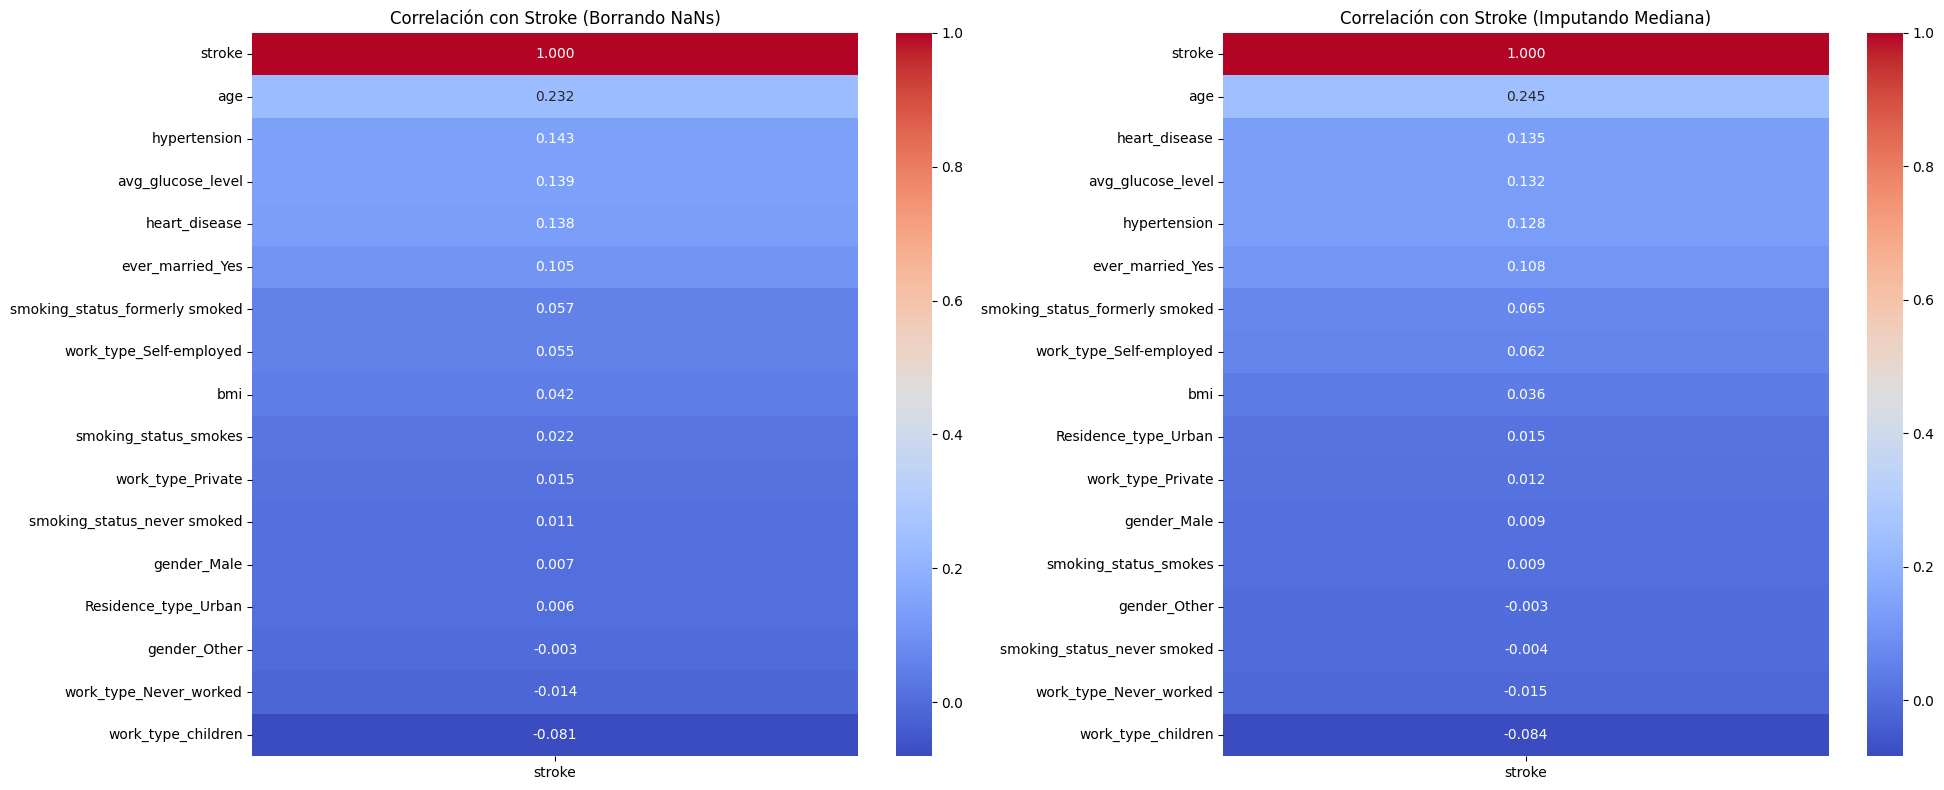

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Caso 1 (Drop)
sns.heatmap(df_drop_encoded.corr()[['stroke']].sort_values(by='stroke', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[0])
axes[0].set_title('Correlación con Stroke (Borrando NaNs)')

# Heatmap Caso 2 (Impute)
sns.heatmap(df_impute_encoded.corr()[['stroke']].sort_values(by='stroke', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1])
axes[1].set_title('Correlación con Stroke (Imputando Mediana)')

plt.tight_layout()
plt.show()

#### Análisis Bivariado: Cruce de variables de Estilo de Vida vs Infarto
Analisis de cómo se distribuyen los infartos dependiendo de si la persona fuma o no.

Caso 1 (Drop)


stroke,0,1
smoking_status,,
Unknown,98.04%,1.96%
formerly smoked,93.19%,6.81%
never smoked,95.46%,4.54%
smokes,94.71%,5.29%



Caso 2 (Impute)


stroke,0,1
smoking_status,,
Unknown,96.96%,3.04%
formerly smoked,92.09%,7.91%
never smoked,95.24%,4.76%
smokes,94.68%,5.32%


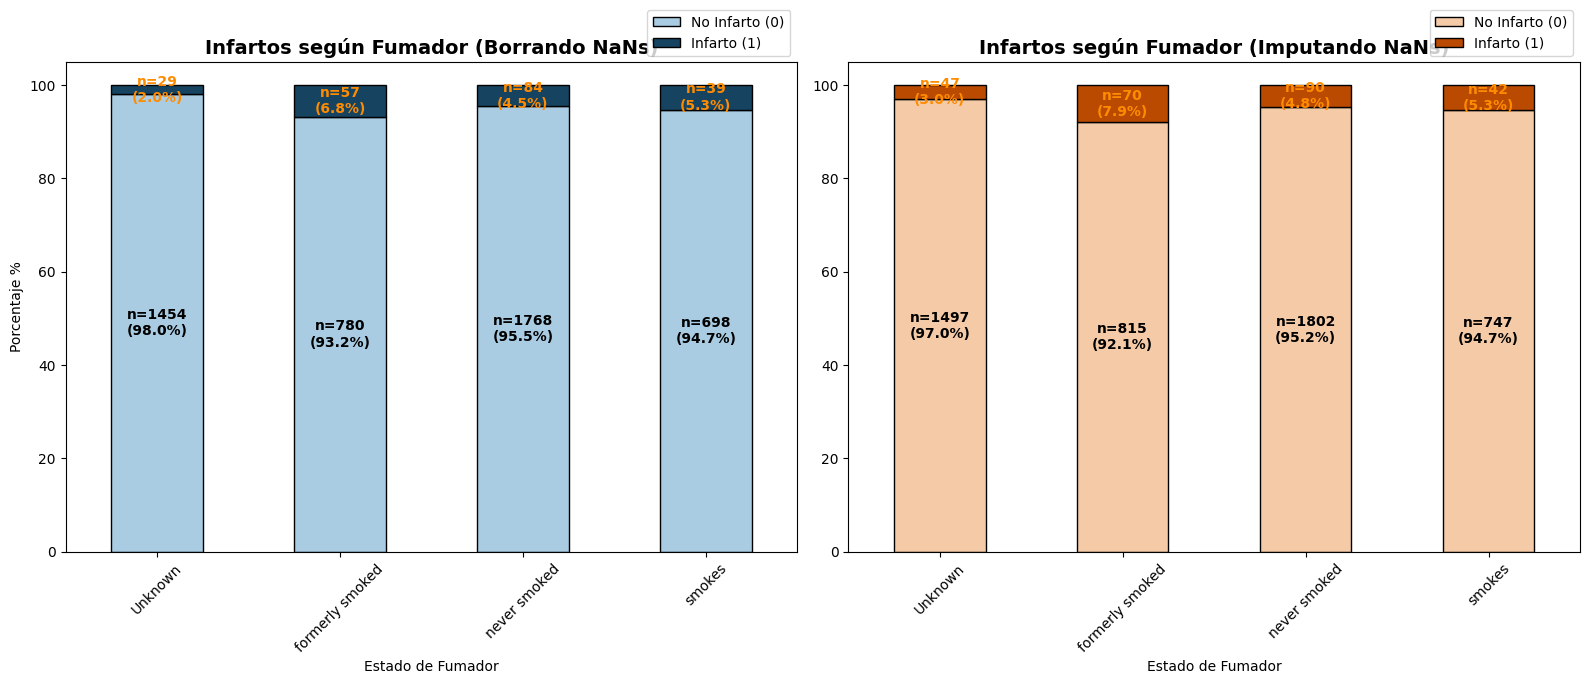

In [17]:
ct_drop_pct = pd.crosstab(df_drop['smoking_status'], df_drop['stroke'], normalize='index') * 100
ct_impute_pct = pd.crosstab(df_impute['smoking_status'], df_impute['stroke'], normalize='index') * 100

ct_drop_count = pd.crosstab(df_drop['smoking_status'], df_drop['stroke'])
ct_impute_count = pd.crosstab(df_impute['smoking_status'], df_impute['stroke'])

print("Caso 1 (Drop)")
display(ct_drop_pct.style.background_gradient(cmap='Blues').format("{:.2f}%"))

print("\nCaso 2 (Impute)")
display(ct_impute_pct.style.background_gradient(cmap='Oranges').format("{:.2f}%"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colores_drop = ['#A9CCE3', '#154360']
colores_impute = ['#F5CBA7', '#BA4A00']

# Caso 1 (Drop)
ct_drop_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colores_drop, edgecolor='black')
axes[0].set_title('Infartos según Fumador (Borrando NaNs)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Porcentaje %')
axes[0].set_xlabel('Estado de Fumador')
axes[0].legend(['No Infarto (0)', 'Infarto (1)'], loc='upper right', bbox_to_anchor=(1, 1.12))
axes[0].tick_params(axis='x', rotation=45)

# Caso 2 (Impute)
ct_impute_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores_impute, edgecolor='black')
axes[1].set_title('Infartos según Fumador (Imputando NaNs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estado de Fumador')
axes[1].legend(['No Infarto (0)', 'Infarto (1)'], loc='upper right', bbox_to_anchor=(1, 1.12))
axes[1].tick_params(axis='x', rotation=45)

def agregar_etiquetas(ax, df_pct, df_count):
    for i, (index, row) in enumerate(df_pct.iterrows()):
        acumulado = 0
        for col in df_pct.columns:
            porcentaje = row[col]
            conteo = df_count.loc[index, col]

            if porcentaje > 0:
                y_pos = acumulado + (porcentaje / 2)
                color_texto = 'darkorange' if col == 1 else 'black'
                ax.text(i, y_pos, f"n={conteo}\n({porcentaje:.1f}%)",
                        ha='center', va='center', color=color_texto, fontweight='bold', fontsize=10)

            acumulado += porcentaje

agregar_etiquetas(axes[0], ct_drop_pct, ct_drop_count)
agregar_etiquetas(axes[1], ct_impute_pct, ct_impute_count)

plt.tight_layout()
plt.show()


#### Comparación de Outliers
El Índice de Masa Corporal (BMI) es una variable que presenta múltiples valores atípicos. El borrar vs imputar los valores nulos afecta la cantidad y distribución de outliers, utilizando diagramas de caja (Boxplots) y el método del Rango Intercuartílico (IQR).

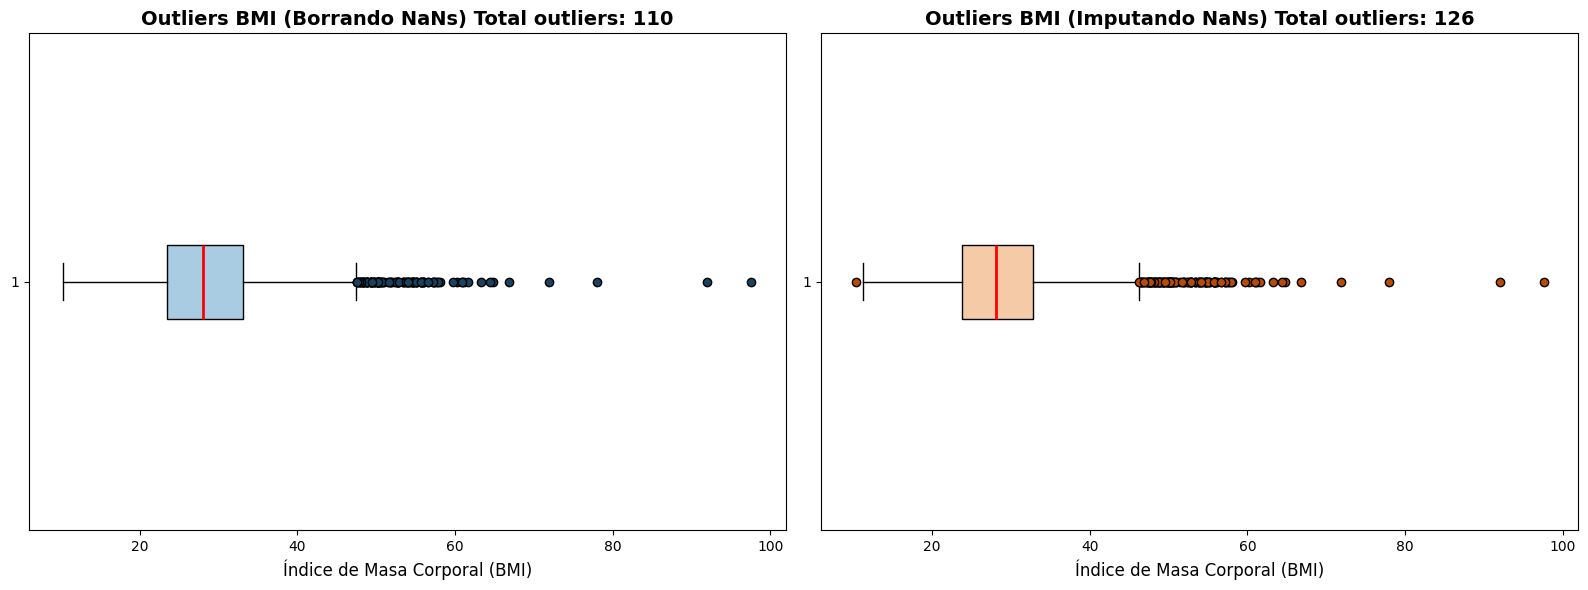

In [18]:
def contar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[columna] < Q1 - 1.5 * IQR) | (df[columna] > Q3 + 1.5 * IQR)]
    return len(outliers)

outliers_drop = contar_outliers(df_drop, 'bmi')
outliers_impute = contar_outliers(df_impute, 'bmi')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Caso 1 (Drop)
axes[0].boxplot(df_drop['bmi'], patch_artist=True, vert=False, boxprops=dict(facecolor='#A9CCE3', color='black'), medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#154360', markeredgecolor='black', markersize=6, linestyle='none'))
axes[0].set_title(f'Outliers BMI (Borrando NaNs) Total outliers: {outliers_drop}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Índice de Masa Corporal (BMI)', fontsize=12)

# Caso 2 (Impute)
axes[1].boxplot(df_impute['bmi'], patch_artist=True, vert=False, boxprops=dict(facecolor='#F5CBA7', color='black'), medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#BA4A00', markeredgecolor='black', markersize=6, linestyle='none'))
axes[1].set_title(f'Outliers BMI (Imputando NaNs) Total outliers: {outliers_impute}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Índice de Masa Corporal (BMI)', fontsize=12)

plt.tight_layout()
plt.show()

 #### Comparación: Distribución del Tipo de Trabajo (Pie Chart)
A continuación, analizaremos si la eliminación de los valores nulos afectó la distribución demográfica de nuestro dataset, específicamente en la variable `work_type` (Tipo de trabajo).

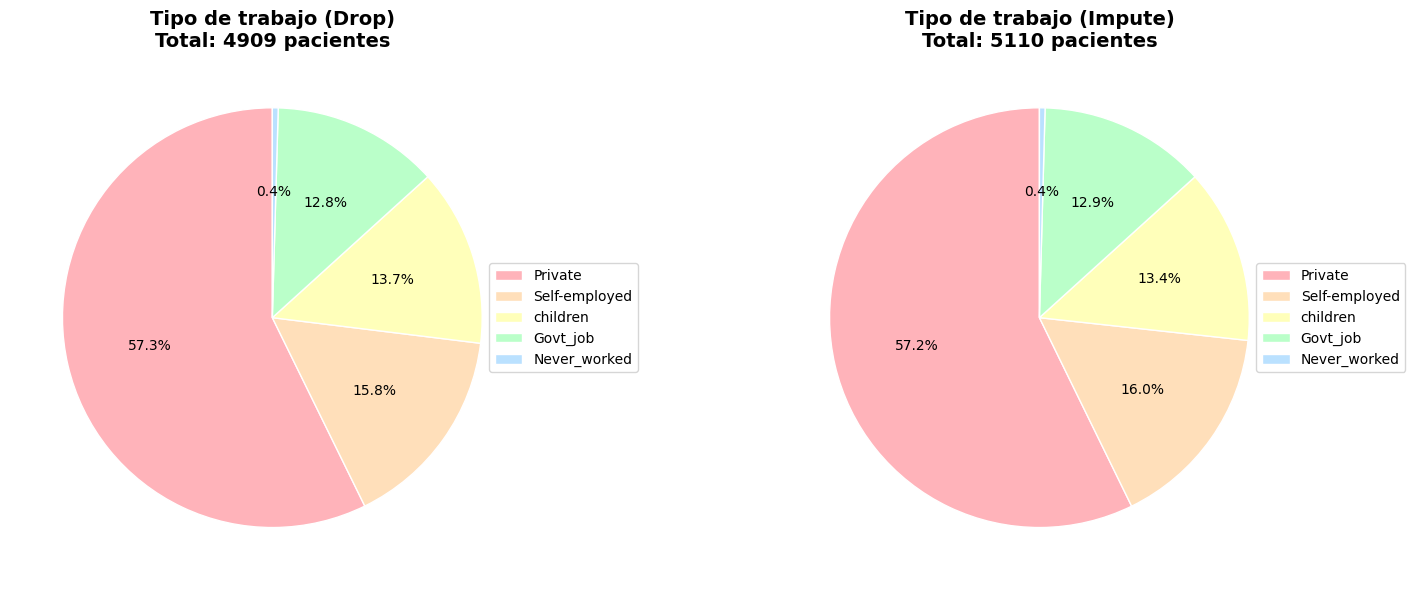

In [19]:
counts_drop = df_drop['work_type'].value_counts()
counts_impute = df_impute['work_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores = ['#FFB3BA','#FFDFBA','#FFFFBA','#BAFFC9','#BAE1FF']

# Caso 1 (Drop)
axes[0].pie(counts_drop, labels=None, autopct='%1.1f%%', startangle=90, colors=colores, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0].set_title(f'Tipo de trabajo (Drop)\nTotal: {len(df_drop)} pacientes', fontsize=14, fontweight='bold')
axes[0].legend(counts_drop.index, loc='center left', bbox_to_anchor=(0.9, 0.5))

# Caso 2 (Impute)
axes[1].pie(counts_impute, labels=None, autopct='%1.1f%%', startangle=90, colors=colores, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title(f'Tipo de trabajo (Impute)\nTotal: {len(df_impute)} pacientes', fontsize=14, fontweight='bold')
axes[1].legend(counts_impute.index, loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.tight_layout()
plt.show()

Particionando 80/20

* El dataset está fuertemente desbalanceado. De 5110 pacientes, solo 249 (aprox. 4.8%) sufrieron un infarto (stroke = 1).

* Caso 1: Realizamos un dropna(), perdemos 201 filas. El analisis demostró que de esas 201 filas, ¡40 corresponden a personas que sufrieron infartos! Es decir, estamos eliminando el 16% de la clase minoritaria y más importante.

* Caso 2: Usamos la mediana en lugar de la media para rellenar la columna bmi (Índice de Masa Corporal). Esta es correcta porque, como se observa en los diagramas de caja (Boxplots), la variable bmi tiene muchos valores atípicos (outliers) hacia arriba. La media es muy sensible a valores extremos, mientras que la mediana es una medida se acerca mas al modelo real.

## Caso 1:


```
Preparacion del Dataset con DropNa
```




In [22]:

X_drop = df_drop_encoded.drop('stroke', axis=1)
y_drop = df_drop_encoded['stroke']
columnas_continuas = ['age', 'avg_glucose_level', 'bmi']

# Particionado 80/20 con stratify
X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(
    X_drop, y_drop, test_size=0.20, random_state=42, shuffle=True, stratify=y_drop
)

# Escalado (Usamos un scaler independiente para no mezclar cálculos matemáticos)
scaler_drop = StandardScaler()

X_train_drop[columnas_continuas] = scaler_drop.fit_transform(X_train_drop[columnas_continuas])
X_test_drop[columnas_continuas] = scaler_drop.transform(X_test_drop[columnas_continuas])

print(f"Train: {X_train_drop.shape} | Test: {X_test_drop.shape}")
print(f"Casos de infarto en Train: {y_train_drop.sum()} | En Test: {y_test_drop.sum()}")

Train: (3927, 16) | Test: (982, 16)
Casos de infarto en Train: 167 | En Test: 42


## Caso 2:
```
Preparacion del dataset Imputado
```

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_impute = df_impute_encoded.drop('stroke', axis=1)
y_impute = df_impute_encoded['stroke']

# Particionado 80/20 con stratify
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_impute, y_impute, test_size=0.20, random_state=42, shuffle=True, stratify=y_impute
)

# Escalado
scaler_imp = StandardScaler()
columnas_continuas = ['age', 'avg_glucose_level', 'bmi']

X_train_imp[columnas_continuas] = scaler_imp.fit_transform(X_train_imp[columnas_continuas])
X_test_imp[columnas_continuas] = scaler_imp.transform(X_test_imp[columnas_continuas])

print(f"Train: {X_train_imp.shape} | Test: {X_test_imp.shape}")
print(f"Casos de infarto en Train: {y_train_imp.sum()} | En Test: {y_test_imp.sum()}\n")

Train: (4088, 16) | Test: (1022, 16)
Casos de infarto en Train: 199 | En Test: 50



## 3 Desicion Tree (DT)

Como nuestro dataset está muy desbalanceado (solo 4.8% de infartos), mirar solo el "Accuracy" (Precisión general) es una trampa mortal. Si el modelo dice "nadie tiene infartos", tendrá un 95% de Accuracy, ¡pero dejará morir a todos los pacientes enfermos! Por eso, al sintonizar (tunear) el max_depth, usaremos una métrica llamada Recall (Sensibilidad), que mide de todos los que realmente tuvieron un infarto, cuántos logró detectar el modelo. Y además, le diremos al modelo que preste más atención a la clase minoritaria usando class_weight='balanced'

In [23]:
def sintonizar_arbol(X_train, y_train, X_test, y_test, nombre_caso):
    print(f"--- SINTONIZACIÓN DE DECISION TREE: {nombre_caso} ---")
    mejor_profundidad = 0
    mejor_recall = 0

    # Probamos profundidades del 1 al 10
    for depth in range(1, 11):
        # class_weight='balanced' es el salvavidas para datasets desbalanceados
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
        dt.fit(X_train, y_train)
        y_pred = dt.predict(X_test)

        # Evaluamos enfocándonos en el Recall de la clase 1 (Infarto)
        recall_infartos = recall_score(y_test, y_pred)

        if recall_infartos > mejor_recall:
            mejor_recall = recall_infartos
            mejor_profundidad = depth

    # Entrenamos el mejor modelo final
    dt_final = DecisionTreeClassifier(max_depth=mejor_profundidad, random_state=42, class_weight='balanced')
    dt_final.fit(X_train, y_train)
    y_pred_final = dt_final.predict(X_test)

    print(f"Mejor max_depth encontrado: {mejor_profundidad}")
    print(f"Reporte de Métricas Final:\n")
    print(classification_report(y_test, y_pred_final))
    print("="*50 + "\n")

    return dt_final

dt_modelo_caso1 = sintonizar_arbol(X_train_drop, y_train_drop, X_test_drop, y_test_drop, "CASO 1 (DROPNA)")

dt_modelo_caso2 = sintonizar_arbol(X_train_imp, y_train_imp, X_test_imp, y_test_imp, "CASO 2 (IMPUTADO)")

--- SINTONIZACIÓN DE DECISION TREE: CASO 1 (DROPNA) ---
Mejor max_depth encontrado: 1
Reporte de Métricas Final:

              precision    recall  f1-score   support

           0       0.99      0.58      0.73       940
           1       0.08      0.86      0.15        42

    accuracy                           0.59       982
   macro avg       0.54      0.72      0.44       982
weighted avg       0.95      0.59      0.71       982


--- SINTONIZACIÓN DE DECISION TREE: CASO 2 (IMPUTADO) ---
Mejor max_depth encontrado: 1
Reporte de Métricas Final:

              precision    recall  f1-score   support

           0       0.99      0.57      0.72       972
           1       0.09      0.84      0.17        50

    accuracy                           0.59      1022
   macro avg       0.54      0.71      0.44      1022
weighted avg       0.94      0.59      0.70      1022




In [28]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, recall_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier

# 1. Definimos las métricas TPR y TNR de forma compatible con sklearn
# TPR es el Recall de la clase 1 (Infarto)
tpr_scorer = make_scorer(recall_score, pos_label=1)
# TNR es el Recall de la clase 0 (Sanos)
tnr_scorer = make_scorer(recall_score, pos_label=0)
acc_scorer = make_scorer(accuracy_score)

def evaluar_validacion_cruzada(X, y, depth, nombre_modelo):
    print(f"--- Evaluación K-Fold CV: {nombre_modelo} (max_depth={depth}) ---")

    # Configuramos el modelo y el K-Fold (10 particiones)
    est = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # Calculamos los scores 10 veces para cada métrica
    s_acc = cross_val_score(est, X, y, cv=kf, scoring=acc_scorer)
    s_tpr = cross_val_score(est, X, y, cv=kf, scoring=tpr_scorer)
    s_tnr = cross_val_score(est, X, y, cv=kf, scoring=tnr_scorer)

    # Imprimimos en el formato exacto que solicitaste
    print("accuracy %.3f (+/- %.5f)" % (np.mean(s_acc), np.std(s_acc)))
    print("tpr      %.3f (+/- %.5f)" % (np.mean(s_tpr), np.std(s_tpr)))
    print("tnr      %.3f (+/- %.5f)" % (np.mean(s_tnr), np.std(s_tnr)))
    print("="*55 + "\n")

# ==========================================
# EJECUCIÓN PARA EL CASO 2 (DATASET IMPUTADO)
# ==========================================
# Evaluamos el Árbol Nivel 1 (Underfitting)
evaluar_validacion_cruzada(X_train_imp, y_train_imp, depth=1, nombre_modelo="Árbol Básico")

# Evaluamos el Árbol Nivel 4 (Punto de Equilibrio)
evaluar_validacion_cruzada(X_train_imp, y_train_imp, depth=4, nombre_modelo="Árbol Óptimo")

--- Evaluación K-Fold CV: Árbol Básico (max_depth=1) ---
accuracy 0.582 (+/- 0.03037)
tpr      0.954 (+/- 0.05885)
tnr      0.563 (+/- 0.03382)

--- Evaluación K-Fold CV: Árbol Óptimo (max_depth=4) ---
accuracy 0.651 (+/- 0.03992)
tpr      0.817 (+/- 0.04433)
tnr      0.643 (+/- 0.04177)



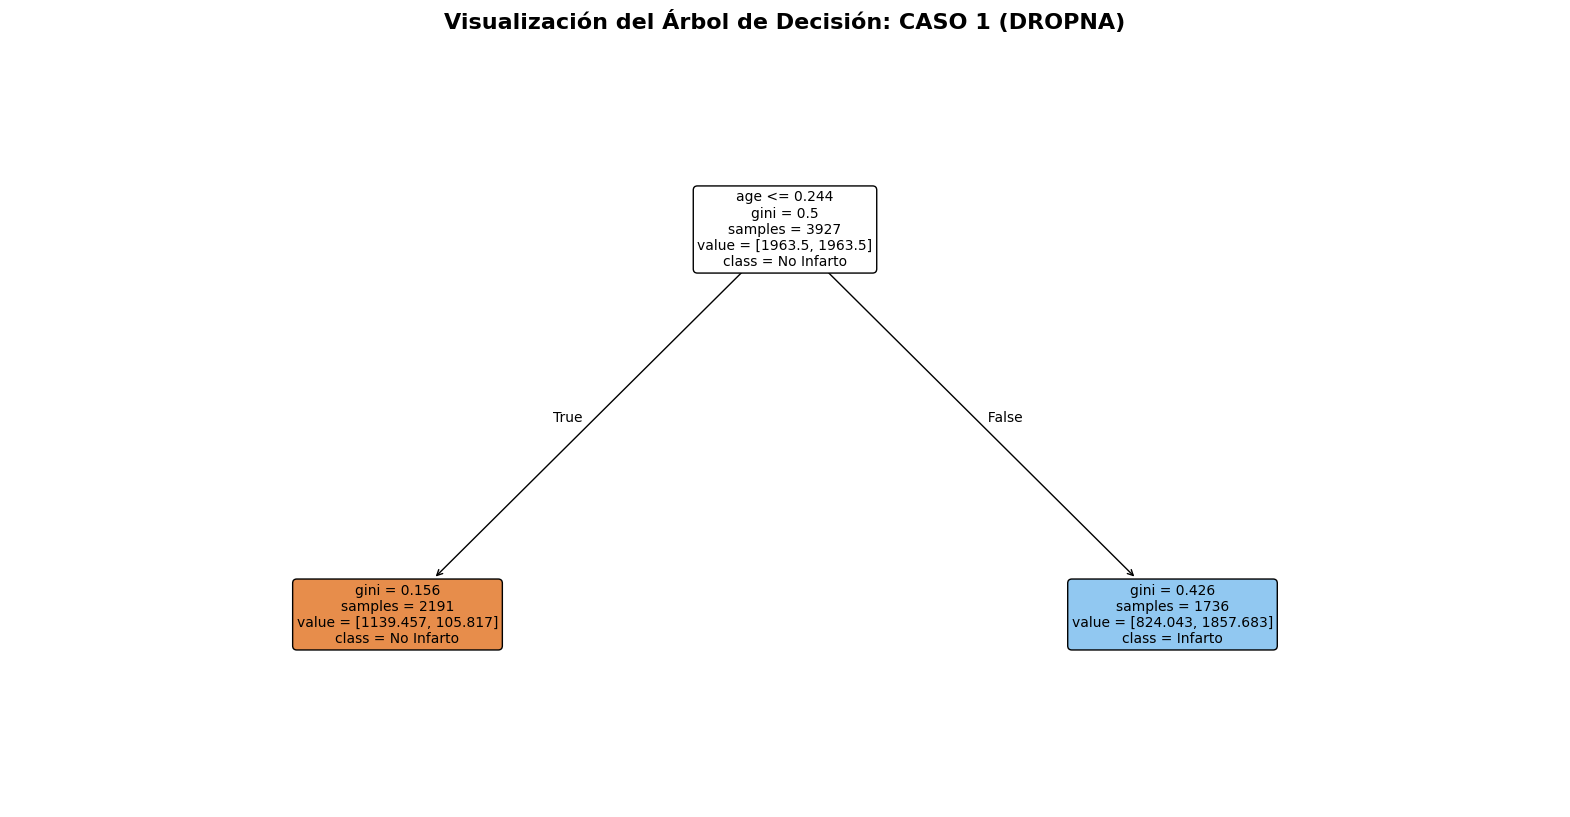

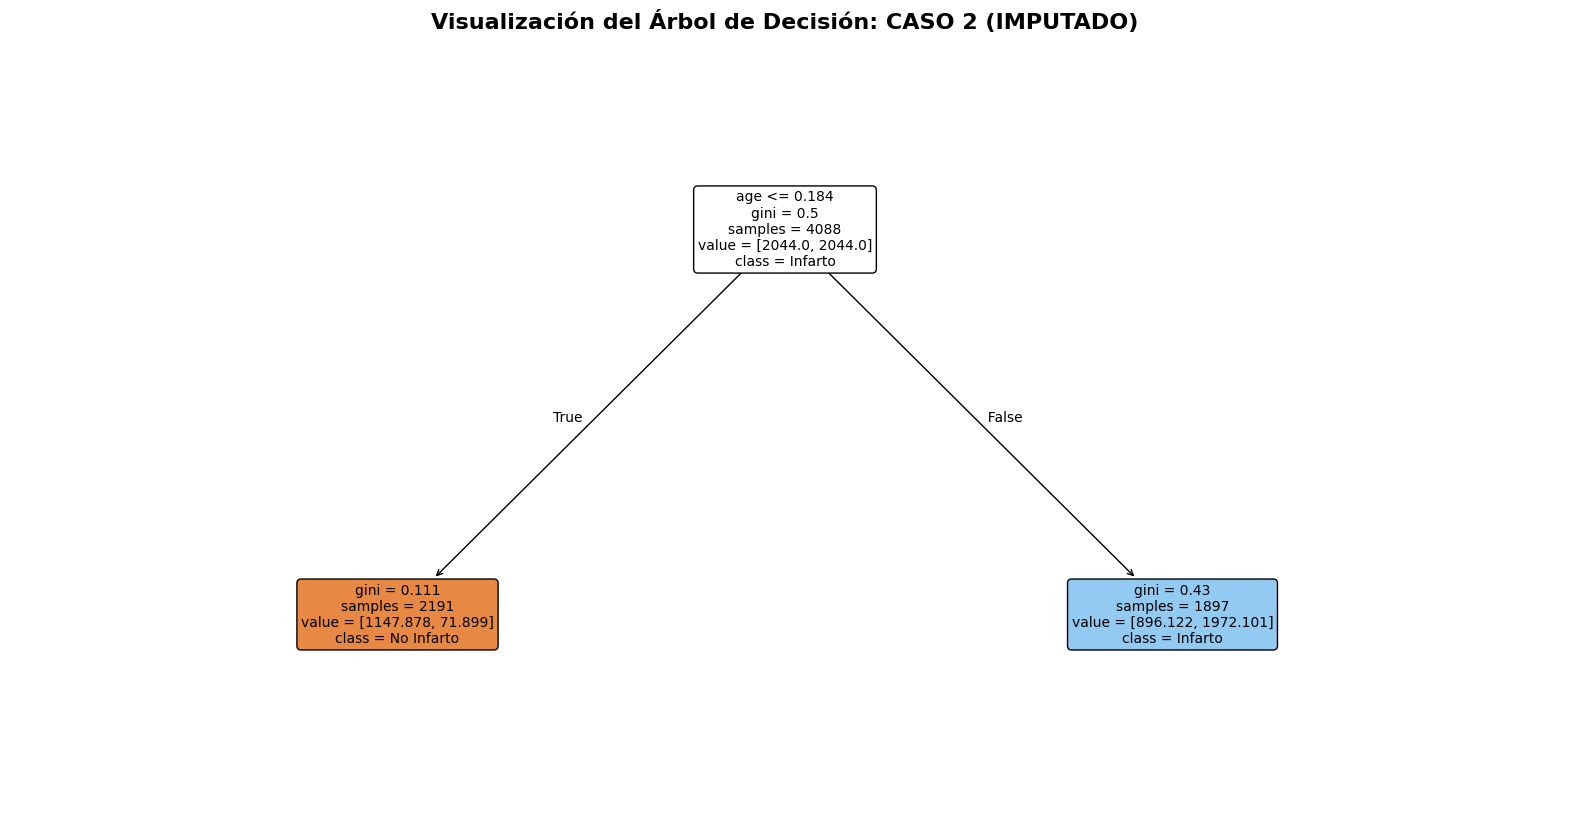

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def graficar_arbol(modelo, columnas, nombre_caso):
    # Configuramos un tamaño grande para que las cajas de texto no se superpongan
    plt.figure(figsize=(20, 10))

    plot_tree(
        modelo,
        feature_names=columnas,
        class_names=['No Infarto', 'Infarto'], # Clase 0 y Clase 1
        filled=True,      # Pinta los nodos: Naranja (Clase 0) y Azul (Clase 1)
        rounded=True,     # Suaviza los bordes de los nodos
        fontsize=10       # Ajusta el tamaño de la letra
    )

    plt.title(f"Visualización del Árbol de Decisión: {nombre_caso}", fontsize=16, fontweight='bold')
    plt.show()
    print("\n")

# Extraemos los nombres de las columnas que usamos para entrenar
nombres_caracteristicas_caso1 = X_train_drop.columns
nombres_caracteristicas_caso2 = X_train_imp.columns

# Graficamos el Caso 1 (Dropna)
graficar_arbol(dt_modelo_caso1, nombres_caracteristicas_caso1, "CASO 1 (DROPNA)")

# Graficamos el Caso 2 (Imputado)
graficar_arbol(dt_modelo_caso2, nombres_caracteristicas_caso2, "CASO 2 (IMPUTADO)")

El Árbol Nivel 4

Accuracy: Sube a 65.2%

Precision: Sube a 10.8%

Recall: Se mantiene en 84.0%

¿Qué pasó? Al dejarlo crecer un poco más para que haga 3 o 4 preguntas adicionales, la Precisión sí aumenta. El modelo es más inteligente, filtra mejor a los pacientes sanos y comete menos falsos positivos sin dejar escapar a los enfermos.

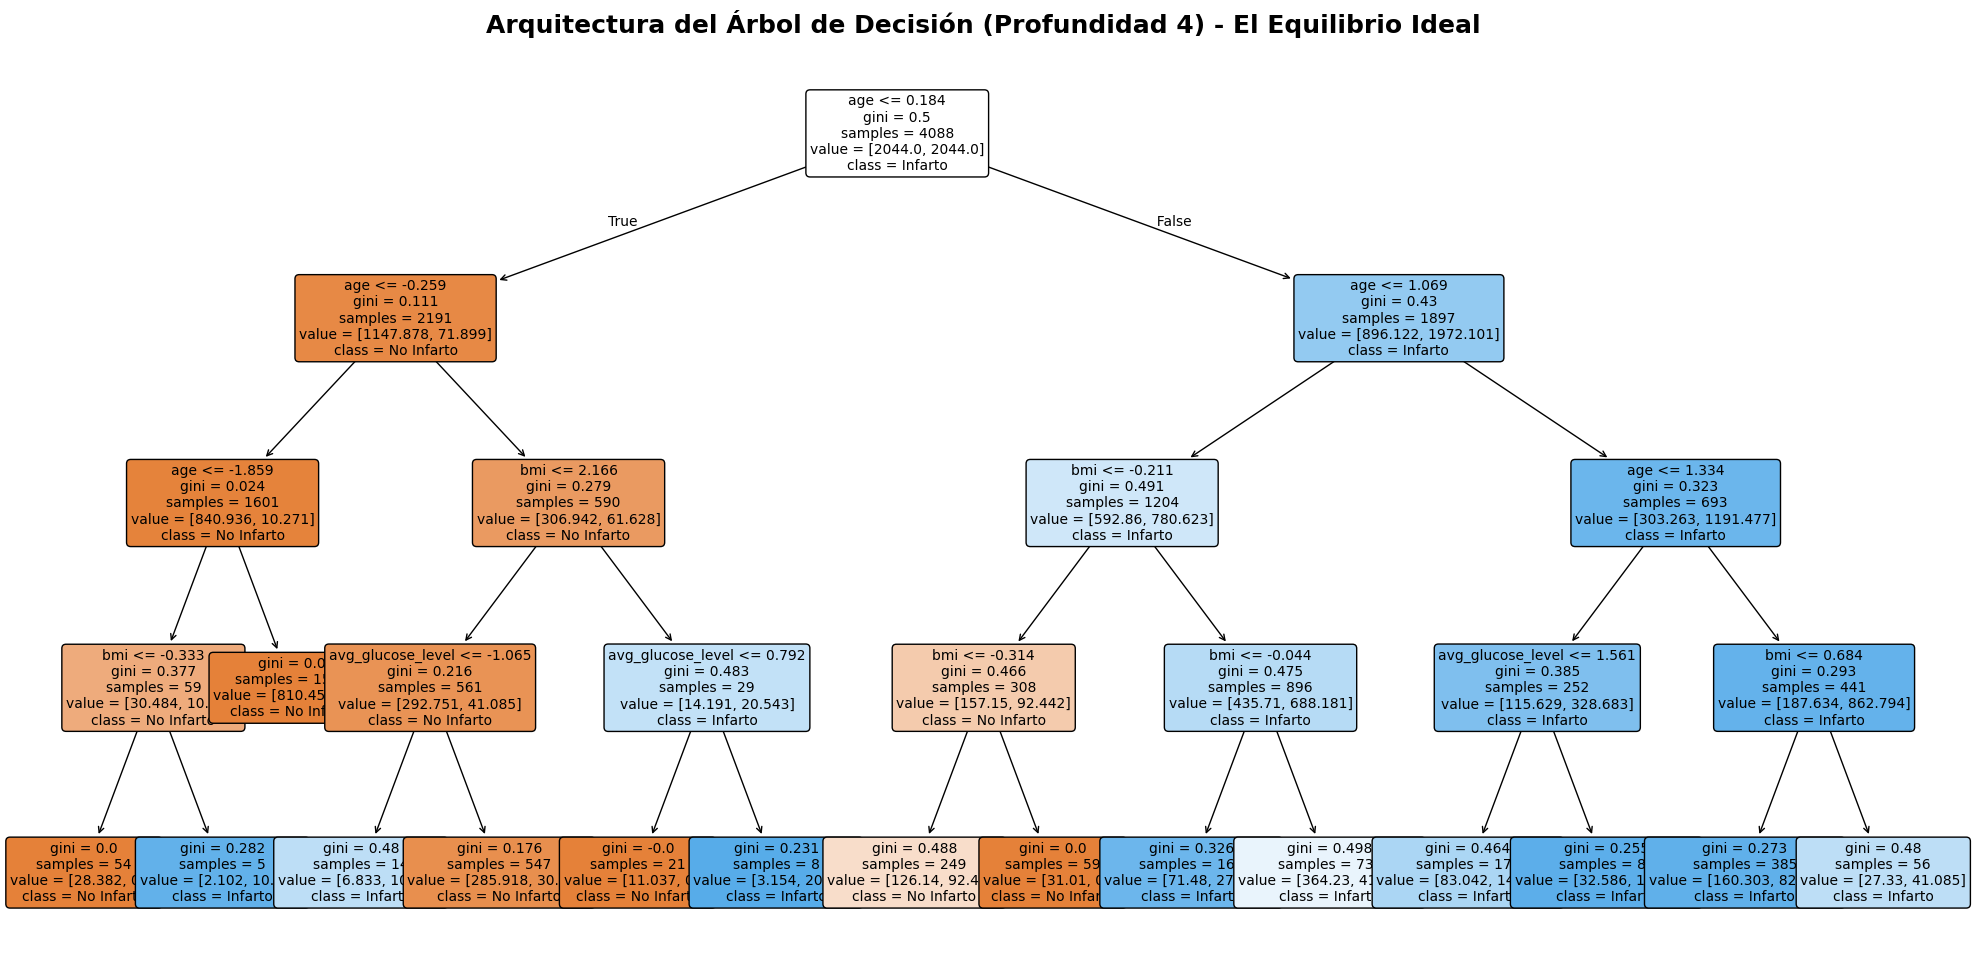

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Entrenamos el modelo específicamente con profundidad 4 usando el Caso 2 (Imputado)
dt_4 = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_4.fit(X_train_imp, y_train_imp)

# 2. Graficamos
plt.figure(figsize=(25, 12)) # Tamaño extra grande para ver bien las ramas
plot_tree(
    dt_4,
    feature_names=X_train_imp.columns,
    class_names=['No Infarto', 'Infarto'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Arquitectura del Árbol de Decisión (Profundidad 4) - El Equilibrio Ideal", fontsize=18, fontweight='bold')
plt.show()

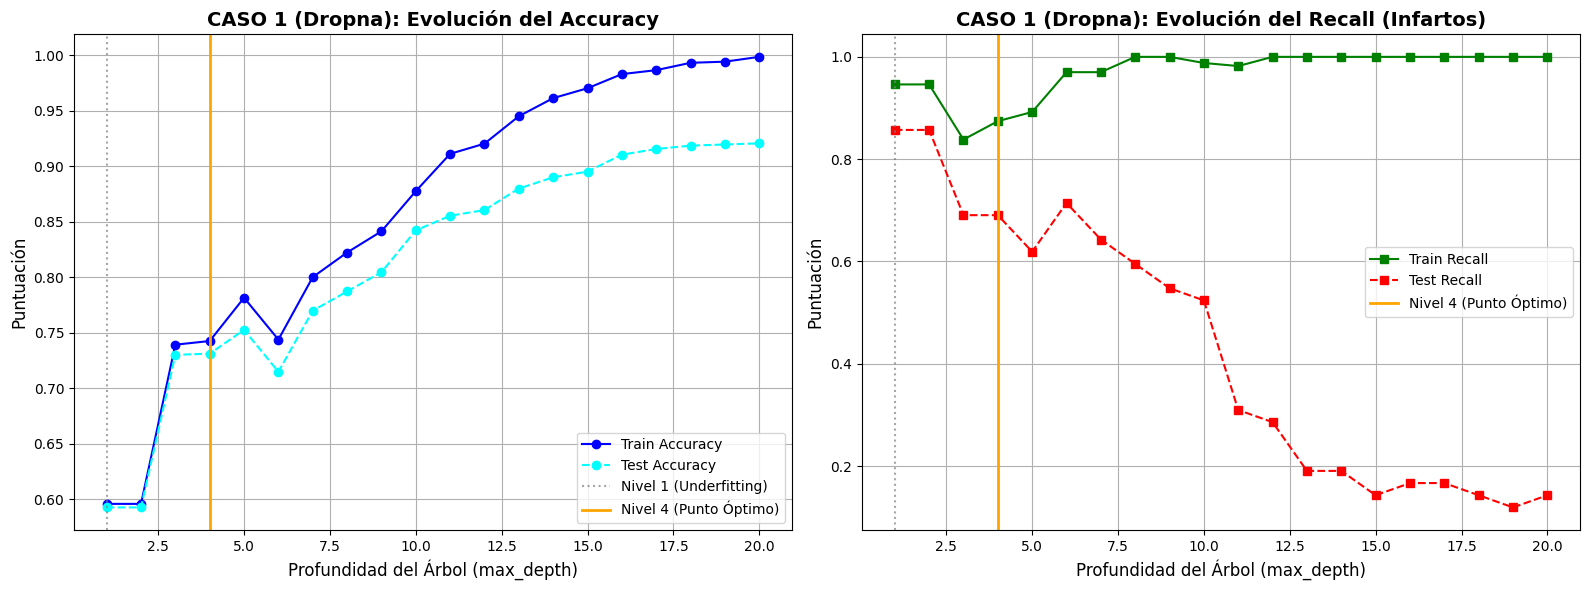

In [31]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score

# 1. Calculamos la evolución creando árboles desde profundidad 1 hasta 20 (Caso 1)
profundidades = range(1, 21)
train_accuracy_c1, test_accuracy_c1 = [], []
train_recall_c1, test_recall_c1 = [], []

for depth in profundidades:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    dt_temp.fit(X_train_drop, y_train_drop)

    y_train_pred = dt_temp.predict(X_train_drop)
    y_test_pred = dt_temp.predict(X_test_drop)

    train_accuracy_c1.append(accuracy_score(y_train_drop, y_train_pred))
    test_accuracy_c1.append(accuracy_score(y_test_drop, y_test_pred))

    train_recall_c1.append(recall_score(y_train_drop, y_train_pred))
    test_recall_c1.append(recall_score(y_test_drop, y_test_pred))

# 2. Generamos las gráficas visuales para el Caso 1
plt.figure(figsize=(16, 6))

# Gráfica 1: Accuracy (Caso 1)
plt.subplot(1, 2, 1)
plt.plot(profundidades, train_accuracy_c1, label='Train Accuracy', marker='o', color='blue')
plt.plot(profundidades, test_accuracy_c1, label='Test Accuracy', marker='o', color='cyan', linestyle='--')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7, label='Nivel 1 (Underfitting)')
plt.axvline(x=4, color='orange', linestyle='-', linewidth=2, label='Nivel 4 (Punto Óptimo)')
plt.title('CASO 1 (Dropna): Evolución del Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfica 2: Recall (Caso 1)
plt.subplot(1, 2, 2)
plt.plot(profundidades, train_recall_c1, label='Train Recall', marker='s', color='green')
plt.plot(profundidades, test_recall_c1, label='Test Recall', marker='s', color='red', linestyle='--')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7)
plt.axvline(x=4, color='orange', linestyle='-', linewidth=2, label='Nivel 4 (Punto Óptimo)')
plt.title('CASO 1 (Dropna): Evolución del Recall (Infartos)', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

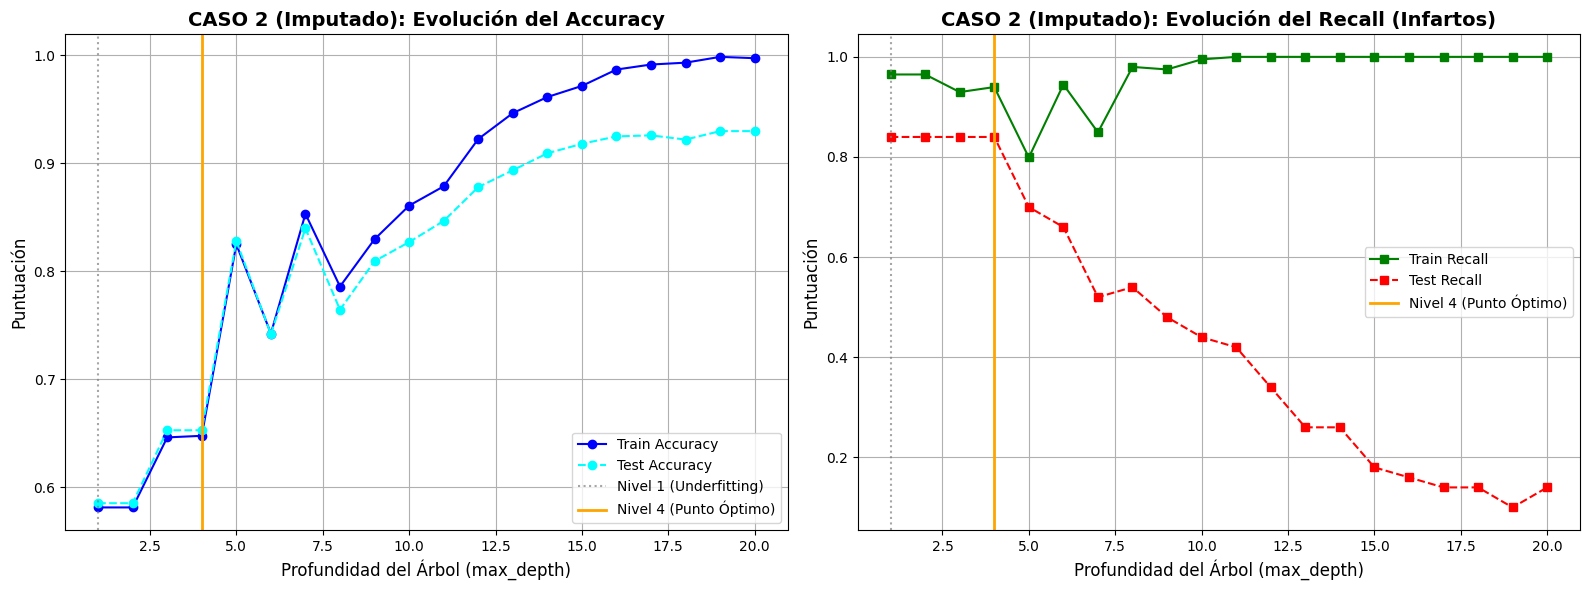

In [32]:
# 1. Calculamos la evolución creando árboles desde profundidad 1 hasta 20 (Caso 2)
profundidades = range(1, 21)
train_accuracy_c2, test_accuracy_c2 = [], []
train_recall_c2, test_recall_c2 = [], []

for depth in profundidades:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    dt_temp.fit(X_train_imp, y_train_imp)

    y_train_pred = dt_temp.predict(X_train_imp)
    y_test_pred = dt_temp.predict(X_test_imp)

    train_accuracy_c2.append(accuracy_score(y_train_imp, y_train_pred))
    test_accuracy_c2.append(accuracy_score(y_test_imp, y_test_pred))

    train_recall_c2.append(recall_score(y_train_imp, y_train_pred))
    test_recall_c2.append(recall_score(y_test_imp, y_test_pred))

# 2. Generamos las gráficas visuales para el Caso 2
plt.figure(figsize=(16, 6))

# Gráfica 1: Accuracy (Caso 2)
plt.subplot(1, 2, 1)
plt.plot(profundidades, train_accuracy_c2, label='Train Accuracy', marker='o', color='blue')
plt.plot(profundidades, test_accuracy_c2, label='Test Accuracy', marker='o', color='cyan', linestyle='--')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7, label='Nivel 1 (Underfitting)')
plt.axvline(x=4, color='orange', linestyle='-', linewidth=2, label='Nivel 4 (Punto Óptimo)')
plt.title('CASO 2 (Imputado): Evolución del Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfica 2: Recall (Caso 2)
plt.subplot(1, 2, 2)
plt.plot(profundidades, train_recall_c2, label='Train Recall', marker='s', color='green')
plt.plot(profundidades, test_recall_c2, label='Test Recall', marker='s', color='red', linestyle='--')
plt.axvline(x=1, color='gray', linestyle=':', alpha=0.7)
plt.axvline(x=4, color='orange', linestyle='-', linewidth=2, label='Nivel 4 (Punto Óptimo)')
plt.title('CASO 2 (Imputado): Evolución del Recall (Infartos)', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

La Trampa: El Árbol Libre / Profundidad Máxima (Overfitting o "Sobreajuste")
¿Qué pasa si lo dejamos crecer hasta que pregunte por el estado civil, el tipo de trabajo, si vive en zona rural, etc.?

Accuracy: Sube al 93.1% (¡Parece excelente!)

Precision: Sube al 18.7%

Recall: ¡Se desploma al 12.0%!

¿Qué pasó? El modelo sufrió Overfitting. El árbol creció tanto que se aprendió "de memoria" a los pacientes del set de entrenamiento. Al darle pacientes nuevos (Test), es incapaz de generalizar. Como la inmensa mayoría de la gente no sufre infartos, el modelo se volvió perezoso y empezó a decir "Nadie tiene infarto". Por eso el Accuracy global es 93% (porque acierta con los sanos), pero dejas morir al 88% de los pacientes enfermos porque el Recall cayó al 12%.

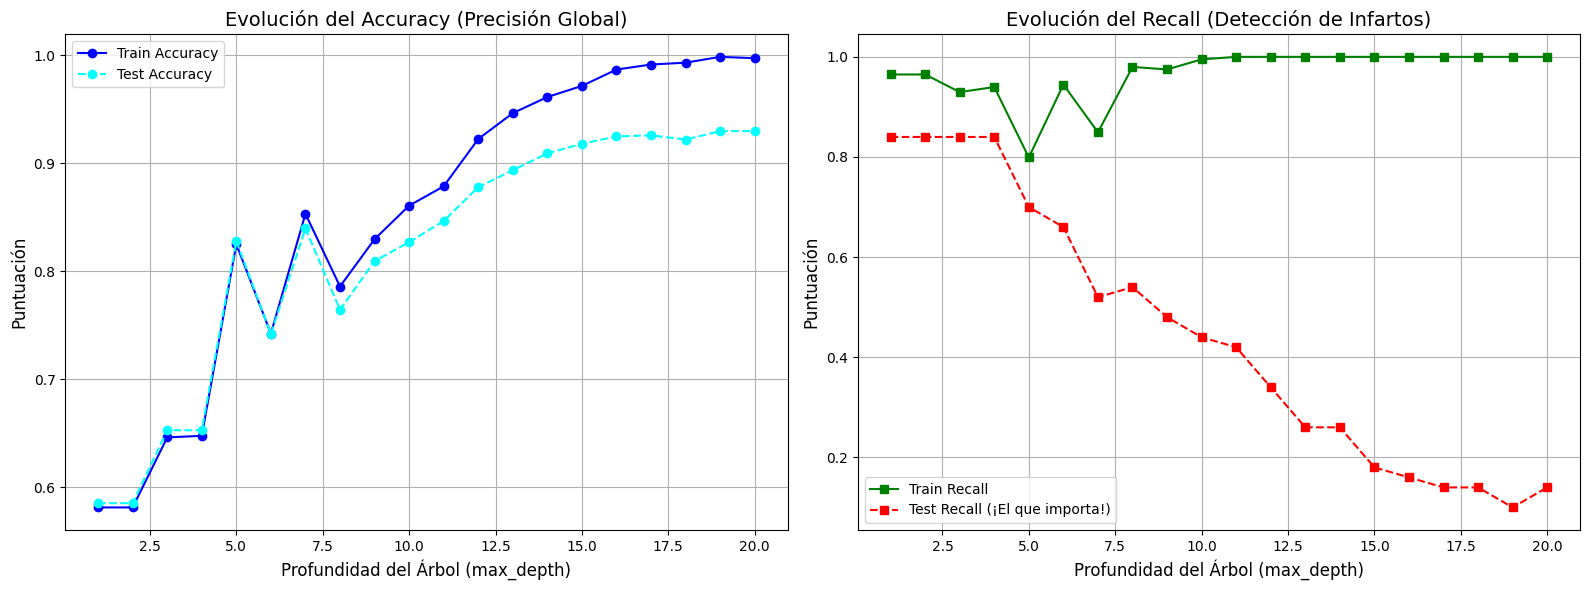

In [26]:
from sklearn.metrics import accuracy_score, recall_score

# Listas para guardar los resultados de cada árbol
profundidades = range(1, 21)
train_accuracy, test_accuracy = [], []
train_recall, test_recall = [], []

# Entrenamos un árbol diferente para cada profundidad (1 al 20)
for depth in profundidades:
    dt_temp = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=42)
    dt_temp.fit(X_train_imp, y_train_imp)

    # Predicciones
    y_train_pred = dt_temp.predict(X_train_imp)
    y_test_pred = dt_temp.predict(X_test_imp)

    # Guardamos el Accuracy
    train_accuracy.append(accuracy_score(y_train_imp, y_train_pred))
    test_accuracy.append(accuracy_score(y_test_imp, y_test_pred))

    # Guardamos el Recall (Lo más importante para nosotros)
    train_recall.append(recall_score(y_train_imp, y_train_pred))
    test_recall.append(recall_score(y_test_imp, y_test_pred))

# ==========================================
# GRAFICAR LOS RESULTADOS
# ==========================================
plt.figure(figsize=(16, 6))

# Gráfica 1: Cómo avanza el Accuracy
plt.subplot(1, 2, 1)
plt.plot(profundidades, train_accuracy, label='Train Accuracy', marker='o', color='blue')
plt.plot(profundidades, test_accuracy, label='Test Accuracy', marker='o', color='cyan', linestyle='--')
plt.title('Evolución del Accuracy (Precisión Global)', fontsize=14)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfica 2: Cómo avanza el Recall (La caída por Overfitting)
plt.subplot(1, 2, 2)
plt.plot(profundidades, train_recall, label='Train Recall', marker='s', color='green')
plt.plot(profundidades, test_recall, label='Test Recall (¡El que importa!)', marker='s', color='red', linestyle='--')
plt.title('Evolución del Recall (Detección de Infartos)', fontsize=14)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bosques Aleatorios (Random Forest - RF)

Si un solo Árbol de Decisión es inestable y propenso al Overfitting (como vimos en las gráficas anteriores cuando la línea roja del Recall se desplomaba), la solución matemática es crear un Random Forest con múltiples árboles de decisión.

En el DT, aumentar la profundidad rompía el modelo (Overfitting). En el RF, aumentar la cantidad de árboles (n_estimators) no causa Overfitting.

Entrenando Random Forest para CASO 1 (Dropna)...


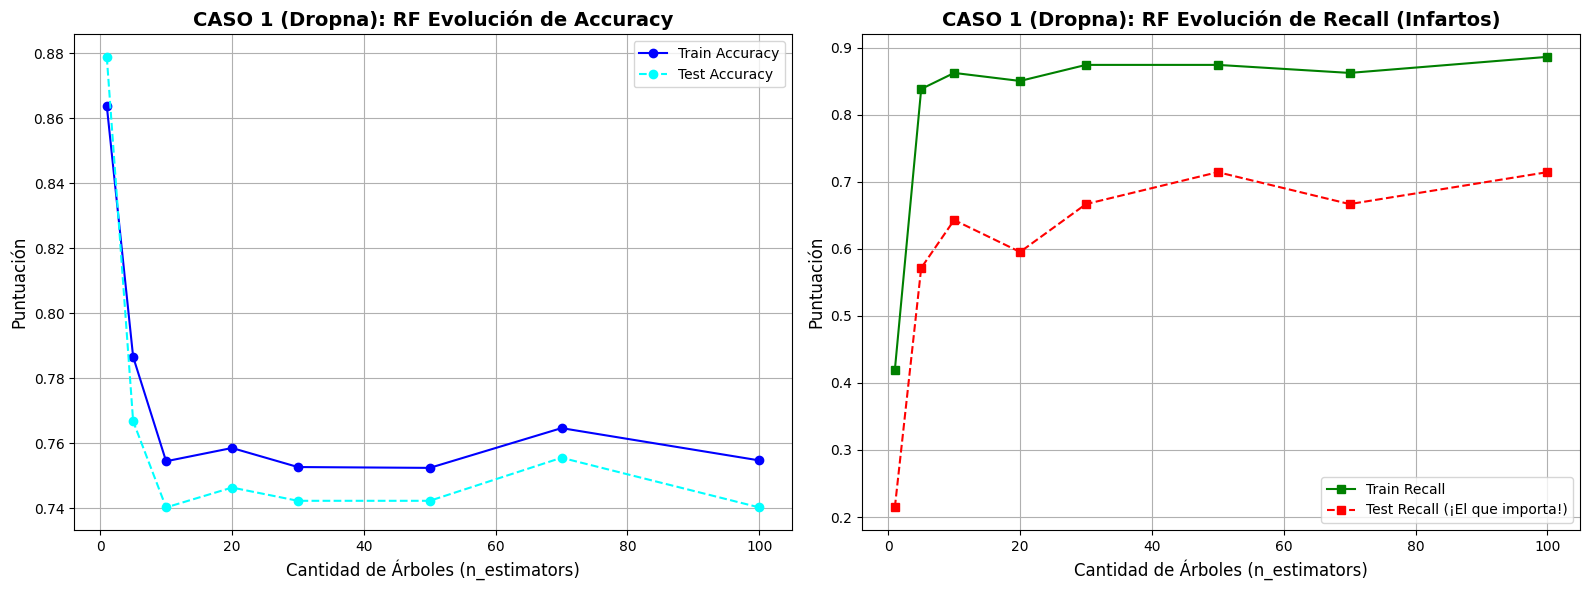

In [33]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

# 1. Definimos la cantidad de árboles a probar (de 1 a 100)
estimadores = [1, 5, 10, 20, 30, 50, 70, 100]

train_accuracy_rf1, test_accuracy_rf1 = [], []
train_recall_rf1, test_recall_rf1 = [], []

print("Entrenando Random Forest para CASO 1 (Dropna)...")
for n in estimadores:
    # Usamos class_weight='balanced' por el desbalanceo y max_depth=4 para mantener la lógica médica
    rf_temp = RandomForestClassifier(n_estimators=n, max_depth=4, class_weight='balanced', random_state=42)
    rf_temp.fit(X_train_drop, y_train_drop)

    y_train_pred = rf_temp.predict(X_train_drop)
    y_test_pred = rf_temp.predict(X_test_drop)

    train_accuracy_rf1.append(accuracy_score(y_train_drop, y_train_pred))
    test_accuracy_rf1.append(accuracy_score(y_test_drop, y_test_pred))

    train_recall_rf1.append(recall_score(y_train_drop, y_train_pred))
    test_recall_rf1.append(recall_score(y_test_drop, y_test_pred))

# 2. Generamos las gráficas visuales para el Caso 1
plt.figure(figsize=(16, 6))

# Gráfica 1: Accuracy RF (Caso 1)
plt.subplot(1, 2, 1)
plt.plot(estimadores, train_accuracy_rf1, label='Train Accuracy', marker='o', color='blue')
plt.plot(estimadores, test_accuracy_rf1, label='Test Accuracy', marker='o', color='cyan', linestyle='--')
plt.title('CASO 1 (Dropna): RF Evolución de Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Árboles (n_estimators)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfica 2: Recall RF (Caso 1)
plt.subplot(1, 2, 2)
plt.plot(estimadores, train_recall_rf1, label='Train Recall', marker='s', color='green')
plt.plot(estimadores, test_recall_rf1, label='Test Recall (¡El que importa!)', marker='s', color='red', linestyle='--')
plt.title('CASO 1 (Dropna): RF Evolución de Recall (Infartos)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Árboles (n_estimators)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Entrenando Random Forest para CASO 2 (Imputado)...


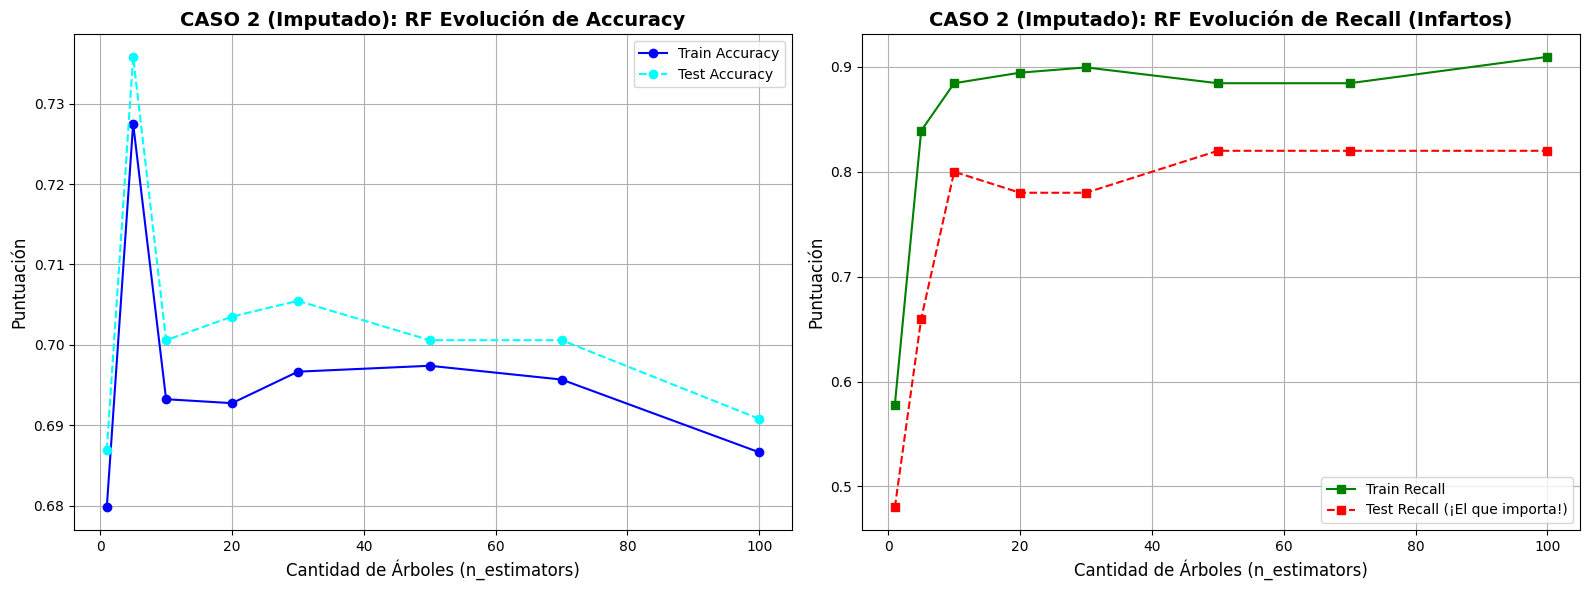

In [34]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

# 1. Calculamos la evolución para el Caso 2 (Imputado)
train_accuracy_rf2, test_accuracy_rf2 = [], []
train_recall_rf2, test_recall_rf2 = [], []

print("Entrenando Random Forest para CASO 2 (Imputado)...")
for n in estimadores:
    rf_temp = RandomForestClassifier(n_estimators=n, max_depth=4, class_weight='balanced', random_state=42)
    rf_temp.fit(X_train_imp, y_train_imp)

    y_train_pred = rf_temp.predict(X_train_imp)
    y_test_pred = rf_temp.predict(X_test_imp)

    train_accuracy_rf2.append(accuracy_score(y_train_imp, y_train_pred))
    test_accuracy_rf2.append(accuracy_score(y_test_imp, y_test_pred))

    train_recall_rf2.append(recall_score(y_train_imp, y_train_pred))
    test_recall_rf2.append(recall_score(y_test_imp, y_test_pred))

# 2. Generamos las gráficas visuales para el Caso 2
plt.figure(figsize=(16, 6))

# Gráfica 1: Accuracy RF (Caso 2)
plt.subplot(1, 2, 1)
plt.plot(estimadores, train_accuracy_rf2, label='Train Accuracy', marker='o', color='blue')
plt.plot(estimadores, test_accuracy_rf2, label='Test Accuracy', marker='o', color='cyan', linestyle='--')
plt.title('CASO 2 (Imputado): RF Evolución de Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Árboles (n_estimators)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

# Gráfica 2: Recall RF (Caso 2)
plt.subplot(1, 2, 2)
plt.plot(estimadores, train_recall_rf2, label='Train Recall', marker='s', color='green')
plt.plot(estimadores, test_recall_rf2, label='Test Recall (¡El que importa!)', marker='s', color='red', linestyle='--')
plt.title('CASO 2 (Imputado): RF Evolución de Recall (Infartos)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Árboles (n_estimators)', fontsize=12)
plt.ylabel('Puntuación', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Máquinas de Vectores de Soporte (SVM)

A diferencia de los árboles que hacen preguntas de "sí/no", el SVM dibuja una línea en el espacio para separar los puntos de los pacientes sanos de los enfermos. Busca el "margen máximo", es decir, la calle más ancha posible entre las dos clases eso es lo que buscamos.

In [35]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, recall_score, accuracy_score

# 1. Definimos nuestras métricas médicas clave
tpr_scorer = make_scorer(recall_score, pos_label=1) # Detección de Infartos
tnr_scorer = make_scorer(recall_score, pos_label=0) # Detección de Sanos
acc_scorer = make_scorer(accuracy_score)            # Precisión Global

def evaluar_svm(X, y, nombre_caso):
    print(f"==================================================")
    print(f" EVALUACIÓN SVM: {nombre_caso}")
    print(f"==================================================\n")

    kernels = ['linear', 'poly', 'rbf']
    kf = KFold(n_splits=5, shuffle=True, random_state=42) # Usamos 5 splits para que no tarde demasiado

    for k in kernels:
        print(f"--- Entrenando Kernel: {k.upper()} ---")
        # class_weight='balanced' sigue siendo OBLIGATORIO por el desbalanceo
        modelo_svm = SVC(kernel=k, class_weight='balanced', random_state=42)

        # Calculamos los scores
        s_acc = cross_val_score(modelo_svm, X, y, cv=kf, scoring=acc_scorer)
        s_tpr = cross_val_score(modelo_svm, X, y, cv=kf, scoring=tpr_scorer)
        s_tnr = cross_val_score(modelo_svm, X, y, cv=kf, scoring=tnr_scorer)

        print("Accuracy global : %.3f (+/- %.5f)" % (np.mean(s_acc), np.std(s_acc)))
        print("TPR (Infartos)  : %.3f (+/- %.5f)" % (np.mean(s_tpr), np.std(s_tpr)))
        print("TNR (Sanos)     : %.3f (+/- %.5f)" % (np.mean(s_tnr), np.std(s_tnr)))
        print("-" * 50)

# ==========================================
# EJECUCIÓN COMPARATIVA (PACIENCIA, PUEDE TARDAR)
# ==========================================
# Evaluamos el Caso 1 (Datos con Dropna)
evaluar_svm(X_train_drop, y_train_drop, "CASO 1 (DROPNA)")

# Evaluamos el Caso 2 (Datos Imputados)
evaluar_svm(X_train_imp, y_train_imp, "CASO 2 (IMPUTADO)")

 EVALUACIÓN SVM: CASO 1 (DROPNA)

--- Entrenando Kernel: LINEAR ---
Accuracy global : 0.748 (+/- 0.01187)
TPR (Infartos)  : 0.802 (+/- 0.05335)
TNR (Sanos)     : 0.745 (+/- 0.01317)
--------------------------------------------------
--- Entrenando Kernel: POLY ---
Accuracy global : 0.820 (+/- 0.00803)
TPR (Infartos)  : 0.556 (+/- 0.04534)
TNR (Sanos)     : 0.832 (+/- 0.00688)
--------------------------------------------------
--- Entrenando Kernel: RBF ---
Accuracy global : 0.796 (+/- 0.01175)
TPR (Infartos)  : 0.622 (+/- 0.03930)
TNR (Sanos)     : 0.804 (+/- 0.01186)
--------------------------------------------------
 EVALUACIÓN SVM: CASO 2 (IMPUTADO)

--- Entrenando Kernel: LINEAR ---
Accuracy global : 0.725 (+/- 0.01235)
TPR (Infartos)  : 0.812 (+/- 0.02938)
TNR (Sanos)     : 0.721 (+/- 0.01248)
--------------------------------------------------
--- Entrenando Kernel: POLY ---
Accuracy global : 0.792 (+/- 0.00358)
TPR (Infartos)  : 0.604 (+/- 0.07385)
TNR (Sanos)     : 0.801 (+/- 0.

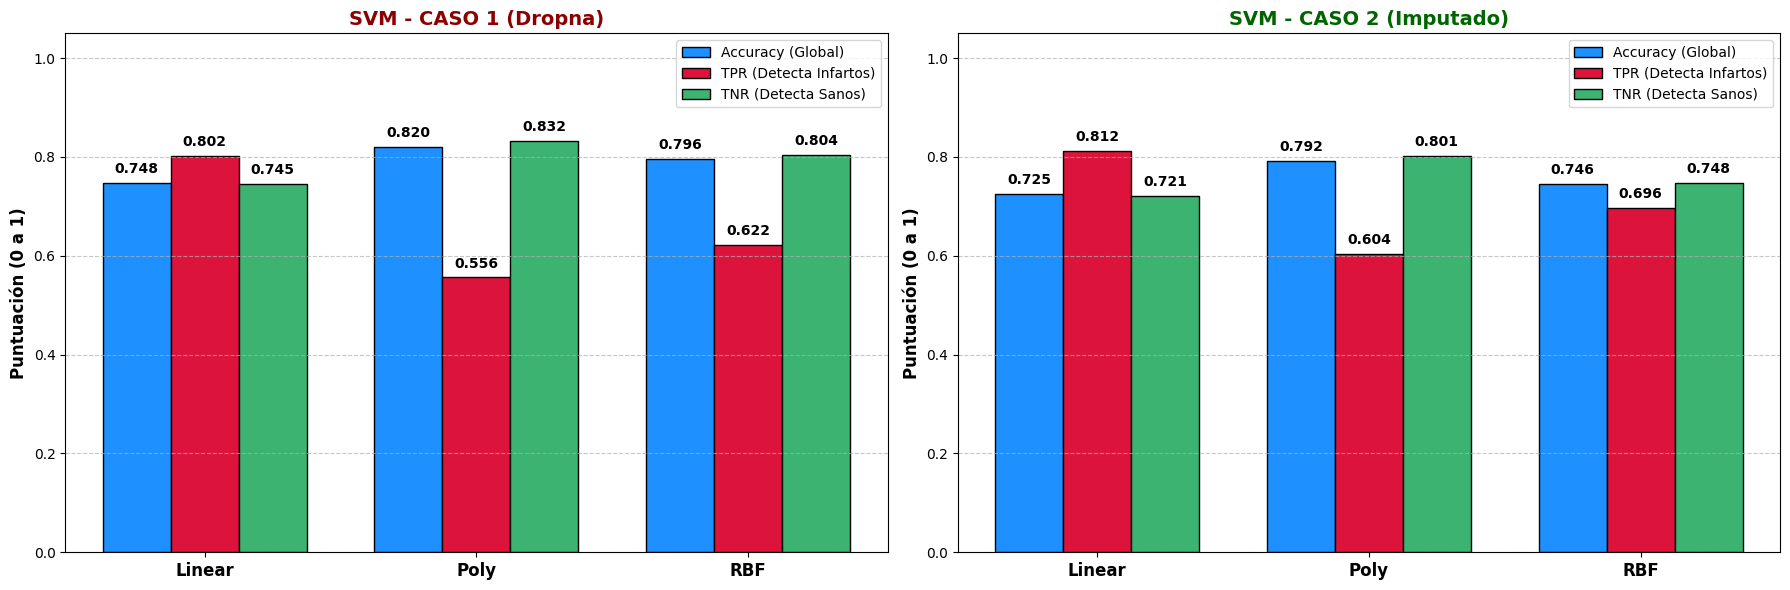

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# TUS DATOS REALES DE LA CONSOLA
# ==========================================
kernels = ['Linear', 'Poly', 'RBF']

# Datos CASO 1 (Dropna)
acc_c1 = [0.748, 0.820, 0.796]
tpr_c1 = [0.802, 0.556, 0.622]
tnr_c1 = [0.745, 0.832, 0.804]

# Datos CASO 2 (Imputado)
acc_c2 = [0.725, 0.792, 0.746]
tpr_c2 = [0.812, 0.604, 0.696]
tnr_c2 = [0.721, 0.801, 0.748]

x = np.arange(len(kernels))
width = 0.25

# ==========================================
# CREACIÓN DEL GRÁFICO DOBLE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

def autolabel(rects, ax):
    """Función para poner los números sobre las barras"""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- GRÁFICA CASO 1 ---
rects1_c1 = ax1.bar(x - width, acc_c1, width, label='Accuracy (Global)', color='dodgerblue', edgecolor='black')
rects2_c1 = ax1.bar(x, tpr_c1, width, label='TPR (Detecta Infartos)', color='crimson', edgecolor='black')
rects3_c1 = ax1.bar(x + width, tnr_c1, width, label='TNR (Detecta Sanos)', color='mediumseagreen', edgecolor='black')

ax1.set_ylabel('Puntuación (0 a 1)', fontsize=12, fontweight='bold')
ax1.set_title('SVM - CASO 1 (Dropna)', fontsize=14, fontweight='bold', color='darkred')
ax1.set_xticks(x)
ax1.set_xticklabels(kernels, fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1_c1, ax1)
autolabel(rects2_c1, ax1)
autolabel(rects3_c1, ax1)

# --- GRÁFICA CASO 2 ---
rects1_c2 = ax2.bar(x - width, acc_c2, width, label='Accuracy (Global)', color='dodgerblue', edgecolor='black')
rects2_c2 = ax2.bar(x, tpr_c2, width, label='TPR (Detecta Infartos)', color='crimson', edgecolor='black')
rects3_c2 = ax2.bar(x + width, tnr_c2, width, label='TNR (Detecta Sanos)', color='mediumseagreen', edgecolor='black')

ax2.set_ylabel('Puntuación (0 a 1)', fontsize=12, fontweight='bold')
ax2.set_title('SVM - CASO 2 (Imputado)', fontsize=14, fontweight='bold', color='darkgreen')
ax2.set_xticks(x)
ax2.set_xticklabels(kernels, fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1_c2, ax2)
autolabel(rects2_c2, ax2)
autolabel(rects3_c2, ax2)

plt.tight_layout()
plt.show()

## Validación Cruzada (K-Fold CV)

El parámetro K divide tus datos en "K" pedazos. Si K=10, entrenas 10 veces usando 9 pedazos y probando con 1.

Si eliges un K muy grande (como K=50):

Costo Computacional: Obligas a tu computadora a entrenar el mismo modelo 50 veces. Para un modelo pesado como SVM, esto puede hacer que tu código tarde horas en ejecutarse sin darte un beneficio real.

El Problema de la Varianza: Si K=50, en cada uno de los 50 entrenamientos el modelo usa el 98% de los datos y solo deja el 2% para probar. Como los sets de entrenamiento son casi idénticos entre sí, los modelos producidos están altamente correlacionados. Por lo tanto la desviación estándar sube ya que matematicamente esto aumenta la varianza de la metrica.


 CASO 1 (DROPNA): BUSCANDO EL MEJOR 'K'

K =  5 | TPR Promedio: 0.622 | Desviación Estándar (Inestabilidad): 0.039
K = 10 | TPR Promedio: 0.677 | Desviación Estándar (Inestabilidad): 0.121
K = 15 | TPR Promedio: 0.663 | Desviación Estándar (Inestabilidad): 0.170
K = 20 | TPR Promedio: 0.647 | Desviación Estándar (Inestabilidad): 0.166
K = 25 | TPR Promedio: 0.669 | Desviación Estándar (Inestabilidad): 0.198
K = 30 | TPR Promedio: 0.666 | Desviación Estándar (Inestabilidad): 0.213
K = 35 | TPR Promedio: 0.655 | Desviación Estándar (Inestabilidad): 0.207


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


K = 40 | TPR Promedio: 0.644 | Desviación Estándar (Inestabilidad): 0.253
K = 45 | TPR Promedio: 0.643 | Desviación Estándar (Inestabilidad): 0.272
K = 50 | TPR Promedio: 0.643 | Desviación Estándar (Inestabilidad): 0.302


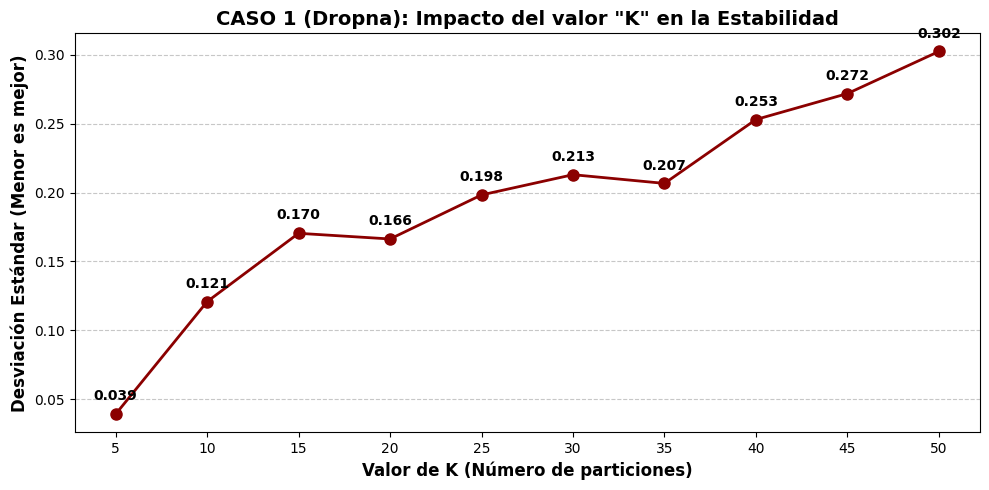

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, recall_score

# 1. Definimos los valores de K a probar
valores_k = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
tpr_promedio_c1 = []
tpr_desviacion_c1 = []

# Usamos el modelo Campeón: SVM RBF
modelo_campeon_c1 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
tpr_scorer = make_scorer(recall_score, pos_label=1)

print("==================================================")
print(" CASO 1 (DROPNA): BUSCANDO EL MEJOR 'K'")
print("==================================================\n")

for k in valores_k:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Entrenamos y evaluamos (X_train_drop, y_train_drop)
    scores = cross_val_score(modelo_campeon_c1, X_train_drop, y_train_drop, cv=kf, scoring=tpr_scorer)

    media = np.mean(scores)
    desviacion = np.std(scores)

    tpr_promedio_c1.append(media)
    tpr_desviacion_c1.append(desviacion)

    print(f"K = {k:2d} | TPR Promedio: {media:.3f} | Desviación Estándar (Inestabilidad): {desviacion:.3f}")

# 2. Gráfico de Inestabilidad (Caso 1)
plt.figure(figsize=(10, 5))
plt.plot(valores_k, tpr_desviacion_c1, marker='o', color='darkred', linewidth=2, markersize=8)

plt.title('CASO 1 (Dropna): Impacto del valor "K" en la Estabilidad', fontsize=14, fontweight='bold')
plt.xlabel('Valor de K (Número de particiones)', fontsize=12, fontweight='bold')
plt.ylabel('Desviación Estándar (Menor es mejor)', fontsize=12, fontweight='bold')
plt.xticks(valores_k)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, txt in enumerate(tpr_desviacion_c1):
    plt.annotate(f'{txt:.3f}', (valores_k[i], tpr_desviacion_c1[i]),
                 xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

En el Caso 1 (Dropna), donde perdimos muchos datos y tenemos muy pocos pacientes con infarto en el set de entrenamiento (menos de 200).

Cuando le pido a la máquina hacer un K=40, el algoritmo divide esos pocos infartos en 40 pedazos diferentes al azar.

Como hay tan pocos infartos, llega un punto en que la partición es tan extrema que a uno de esos 40 pedazos no le toca NINGÚN paciente con infarto.

Cuando el modelo intenta evaluar en ese pedazo y calcular el Recall (Sensibilidad), la fórmula matemática es:

* $$\frac{Infartos Detectados}{Total de Infartos Reales}$$

Como el "Total de Infartos Reales" en ese pedacito es 0, ocurre una división por cero (X / 0). Lanza la advertencia y pone la métrica en 0.0.

 CASO 2 (IMPUTADO): BUSCANDO EL MEJOR 'K'

K =  5 | TPR Promedio: 0.696 | Desviación Estándar (Inestabilidad): 0.081
K = 10 | TPR Promedio: 0.705 | Desviación Estándar (Inestabilidad): 0.081
K = 15 | TPR Promedio: 0.688 | Desviación Estándar (Inestabilidad): 0.143
K = 20 | TPR Promedio: 0.683 | Desviación Estándar (Inestabilidad): 0.168
K = 25 | TPR Promedio: 0.654 | Desviación Estándar (Inestabilidad): 0.226
K = 30 | TPR Promedio: 0.659 | Desviación Estándar (Inestabilidad): 0.252
K = 35 | TPR Promedio: 0.671 | Desviación Estándar (Inestabilidad): 0.273
K = 40 | TPR Promedio: 0.659 | Desviación Estándar (Inestabilidad): 0.265


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


K = 45 | TPR Promedio: 0.680 | Desviación Estándar (Inestabilidad): 0.305


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


K = 50 | TPR Promedio: 0.660 | Desviación Estándar (Inestabilidad): 0.310


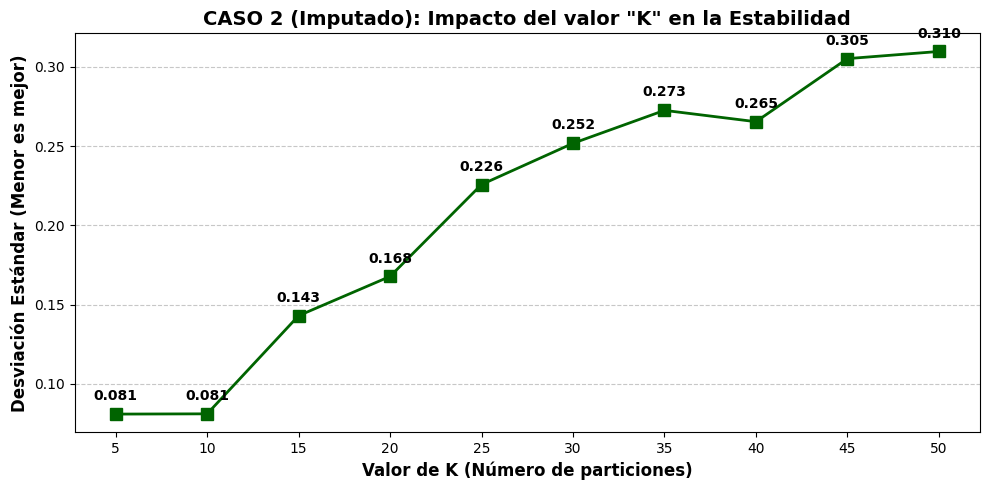

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, recall_score

# 1. Definimos los valores de K a probar
valores_k = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
tpr_promedio_c2 = []
tpr_desviacion_c2 = []

# Usamos el modelo Campeón: SVM RBF
modelo_campeon_c2 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
tpr_scorer = make_scorer(recall_score, pos_label=1)

print("==================================================")
print(" CASO 2 (IMPUTADO): BUSCANDO EL MEJOR 'K'")
print("==================================================\n")

for k in valores_k:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Entrenamos y evaluamos (X_train_imp, y_train_imp)
    scores = cross_val_score(modelo_campeon_c2, X_train_imp, y_train_imp, cv=kf, scoring=tpr_scorer)

    media = np.mean(scores)
    desviacion = np.std(scores)

    tpr_promedio_c2.append(media)
    tpr_desviacion_c2.append(desviacion)

    print(f"K = {k:2d} | TPR Promedio: {media:.3f} | Desviación Estándar (Inestabilidad): {desviacion:.3f}")

# 2. Gráfico de Inestabilidad (Caso 2)
plt.figure(figsize=(10, 5))
plt.plot(valores_k, tpr_desviacion_c2, marker='s', color='darkgreen', linewidth=2, markersize=8)

plt.title('CASO 2 (Imputado): Impacto del valor "K" en la Estabilidad', fontsize=14, fontweight='bold')
plt.xlabel('Valor de K (Número de particiones)', fontsize=12, fontweight='bold')
plt.ylabel('Desviación Estándar (Menor es mejor)', fontsize=12, fontweight='bold')
plt.xticks(valores_k)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, txt in enumerate(tpr_desviacion_c2):
    plt.annotate(f'{txt:.3f}', (valores_k[i], tpr_desviacion_c2[i]),
                 xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Cambio del modelo KFold a StratifiedKFold

 CASO 1 (DROPNA): STRATIFIED K-FOLD (Sin Errores)

K =  5 | TPR Promedio: 0.604 | Desviación Estándar: 0.119
K = 10 | TPR Promedio: 0.683 | Desviación Estándar: 0.127
K = 15 | TPR Promedio: 0.696 | Desviación Estándar: 0.131
K = 20 | TPR Promedio: 0.678 | Desviación Estándar: 0.141
K = 25 | TPR Promedio: 0.667 | Desviación Estándar: 0.159
K = 30 | TPR Promedio: 0.669 | Desviación Estándar: 0.179
K = 35 | TPR Promedio: 0.680 | Desviación Estándar: 0.223
K = 40 | TPR Promedio: 0.667 | Desviación Estándar: 0.218
K = 45 | TPR Promedio: 0.674 | Desviación Estándar: 0.251
K = 50 | TPR Promedio: 0.662 | Desviación Estándar: 0.239
 CASO 2 (IMPUTADO): STRATIFIED K-FOLD (Sin Errores)

K =  5 | TPR Promedio: 0.698 | Desviación Estándar: 0.029
K = 10 | TPR Promedio: 0.709 | Desviación Estándar: 0.109
K = 15 | TPR Promedio: 0.704 | Desviación Estándar: 0.140
K = 20 | TPR Promedio: 0.709 | Desviación Estándar: 0.184
K = 25 | TPR Promedio: 0.713 | Desviación Estándar: 0.180
K = 30 | TPR Promedio: 0.7

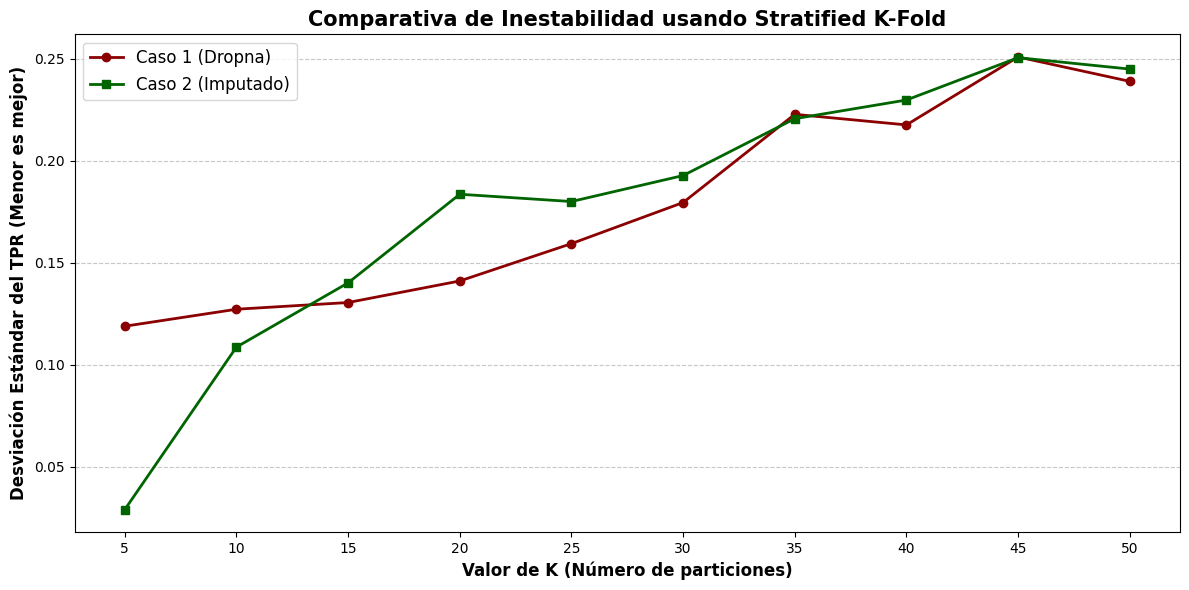

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, recall_score

valores_k = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
tpr_scorer = make_scorer(recall_score, pos_label=1)

def evaluar_estratificado(X, y, nombre_caso, color_linea):
    print(f"==================================================")
    print(f" {nombre_caso}: STRATIFIED K-FOLD (Sin Errores)")
    print(f"==================================================\n")

    modelo = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    desviaciones = []

    for k in valores_k:
        # AQUÍ ESTÁ LA MAGIA: StratifiedKFold en lugar de KFold
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        scores = cross_val_score(modelo, X, y, cv=skf, scoring=tpr_scorer)

        media = np.mean(scores)
        desviacion = np.std(scores)
        desviaciones.append(desviacion)

        print(f"K = {k:2d} | TPR Promedio: {media:.3f} | Desviación Estándar: {desviacion:.3f}")

    return desviaciones

# Ejecutamos ambos casos
desv_c1 = evaluar_estratificado(X_train_drop, y_train_drop, "CASO 1 (DROPNA)", "darkred")
desv_c2 = evaluar_estratificado(X_train_imp, y_train_imp, "CASO 2 (IMPUTADO)", "darkgreen")

# Graficamos la comparación de inestabilidad
plt.figure(figsize=(12, 6))
plt.plot(valores_k, desv_c1, marker='o', color='darkred', label='Caso 1 (Dropna)', linewidth=2)
plt.plot(valores_k, desv_c2, marker='s', color='darkgreen', label='Caso 2 (Imputado)', linewidth=2)

plt.title('Comparativa de Inestabilidad usando Stratified K-Fold', fontsize=15, fontweight='bold')
plt.xlabel('Valor de K (Número de particiones)', fontsize=12, fontweight='bold')
plt.ylabel('Desviación Estándar del TPR (Menor es mejor)', fontsize=12, fontweight='bold')
plt.xticks(valores_k)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

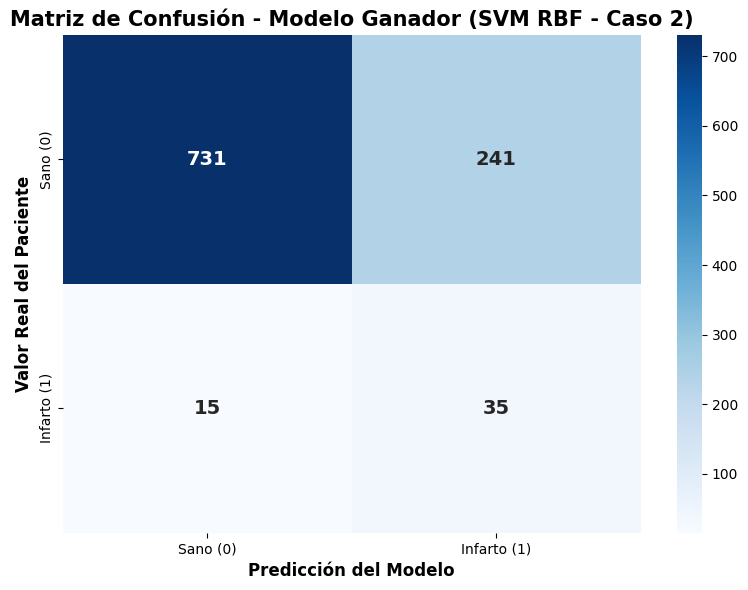

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC

# 1. Entrenamos el mejor modelo final (SVM RBF, Caso 2)
modelo_final = SVC(kernel='rbf', class_weight='balanced', random_state=42)
modelo_final.fit(X_train_imp, y_train_imp)

# 2. Hacemos las predicciones con los datos de prueba
y_pred_final = modelo_final.predict(X_test_imp)

# 3. Calculamos la matriz de confusión
matriz = confusion_matrix(y_test_imp, y_pred_final)

# 4. Graficamos con Seaborn para que luzca profesional
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano (0)', 'Infarto (1)'],
            yticklabels=['Sano (0)', 'Infarto (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión - Modelo Ganador (SVM RBF - Caso 2)', fontsize=15, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real del Paciente', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Las Redes Neuronales son extremadamente hambrientas de datos. Un Árbol o un SVM pueden funcionar bien con pocos datos, un MLP tiene miles de "pesos" (weights) que ajustar matemáticamente mediante un proceso llamado Backpropagation.

Modelo 1 (3 capas: 64, 128, 128): Para un dataset tabular médico de tamaño mediano (aprox. 5000 filas), esta cifra razonable. Tiene suficiente capacidad para aprender patrones no lineales sin volverse loca.

Modelo 2 (6 capas: 64, 64, 128, 128, 256, 256) Aquí tengo exceso de parámetros. Tengo más neuronas en las capas finales que características de entrada. Esto conduce a Overfitting, la red memoriza a los pacientes en lugar de entender la enfermedad.

Modelo 3 (10 capas de 128) En Deep Learning, hacer una red demasiado profunda para un problema sencillo causa el Desvanecimiento del Gradiente (Vanishing Gradient). La señal matemática se pierde al viajar por tantas capas hacia atrás, y las primeras capas nunca aprenden nada útil.

La Trampa del Desbalanceo en MLP: A diferencia de SVM o Decision Trees, el algoritmo estándar de MLP en sklearn no tiene el parámetro class_weight='balanced'. Por lo tanto, la red neuronal sufrirá muchísimo con el desbalanceo (tiende a predecir que todos están sanos).

 DEEP LEARNING (MLP) - CASO 1 (DROPNA)

Entrenando Modelo 1 (3 Capas)...
Accuracy Global : 0.927
TPR (Infartos)  : 0.119
--------------------------------------------------
Entrenando Modelo 2 (6 Capas)...
Accuracy Global : 0.929
TPR (Infartos)  : 0.048
--------------------------------------------------
Entrenando Modelo 3 (10 Capas)...
Accuracy Global : 0.925
TPR (Infartos)  : 0.024
--------------------------------------------------
 DEEP LEARNING (MLP) - CASO 2 (IMPUTADO)

Entrenando Modelo 1 (3 Capas)...
Accuracy Global : 0.924
TPR (Infartos)  : 0.080
--------------------------------------------------
Entrenando Modelo 2 (6 Capas)...
Accuracy Global : 0.911
TPR (Infartos)  : 0.180
--------------------------------------------------
Entrenando Modelo 3 (10 Capas)...
Accuracy Global : 0.918
TPR (Infartos)  : 0.100
--------------------------------------------------


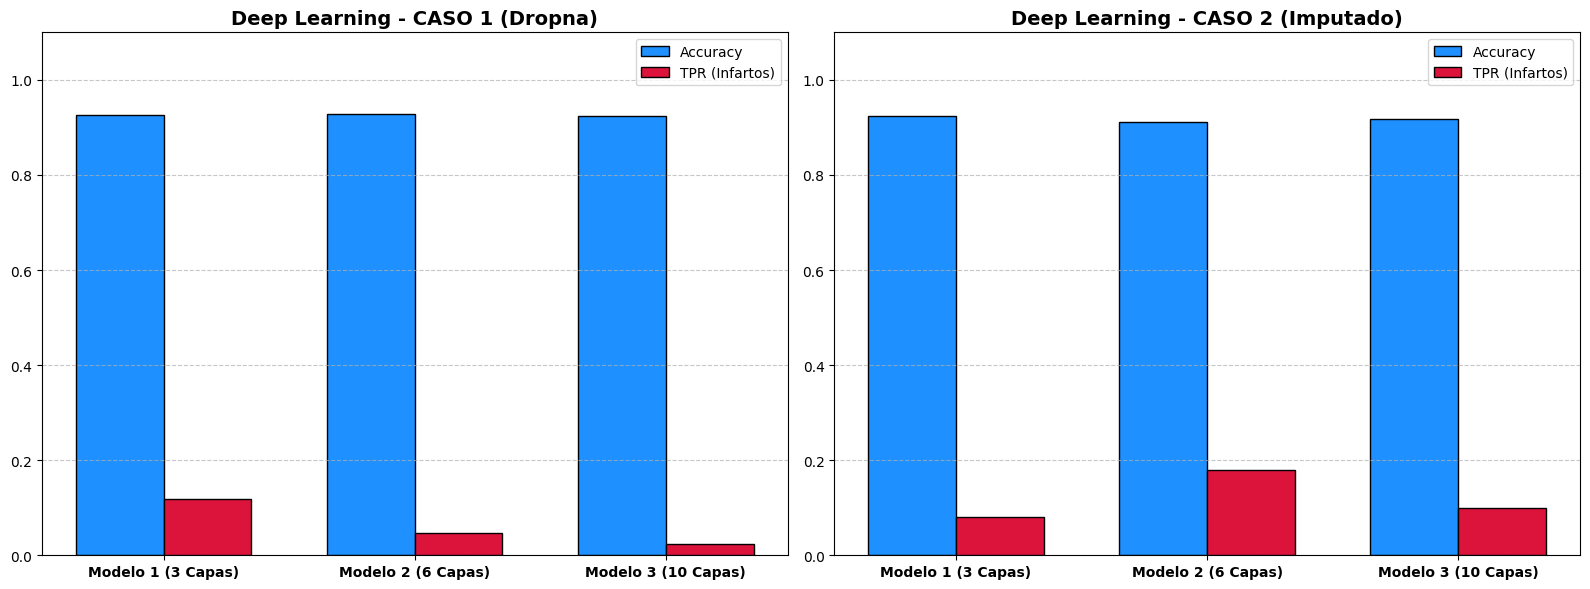

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score, accuracy_score

# 1. Definimos las 3 arquitecturas solicitadas
arquitecturas = {
    "Modelo 1 (3 Capas)": (64, 128, 128),
    "Modelo 2 (6 Capas)": (64, 64, 128, 128, 256, 256),
    "Modelo 3 (10 Capas)": (128, 128, 128, 128, 128, 128, 128, 128, 128, 128)
}

def evaluar_deep_learning(X_train, y_train, X_test, y_test, nombre_caso):
    print(f"==================================================")
    print(f" DEEP LEARNING (MLP) - {nombre_caso}")
    print(f"==================================================\n")

    resultados_acc = []
    resultados_tpr = []
    nombres = list(arquitecturas.keys())

    for nombre, capas in arquitecturas.items():
        print(f"Entrenando {nombre}...")
        # max_iter=1000 para darle tiempo a la red de aprender
        mlp = MLPClassifier(hidden_layer_sizes=capas, activation='relu', solver='adam',
                            max_iter=1000, random_state=42)

        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        tpr = recall_score(y_test, y_pred) # Recall de infartos

        resultados_acc.append(acc)
        resultados_tpr.append(tpr)

        print(f"Accuracy Global : {acc:.3f}")
        print(f"TPR (Infartos)  : {tpr:.3f}")
        print("-" * 50)

    return nombres, resultados_acc, resultados_tpr

# 2. Ejecutamos para Caso 1 y Caso 2
nombres, acc_c1, tpr_c1 = evaluar_deep_learning(X_train_drop, y_train_drop, X_test_drop, y_test_drop, "CASO 1 (DROPNA)")
_, acc_c2, tpr_c2 = evaluar_deep_learning(X_train_imp, y_train_imp, X_test_imp, y_test_imp, "CASO 2 (IMPUTADO)")

# 3. Gráfica comparativa visual
x = np.arange(len(nombres))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica Caso 1
ax1.bar(x - width/2, acc_c1, width, label='Accuracy', color='dodgerblue', edgecolor='black')
ax1.bar(x + width/2, tpr_c1, width, label='TPR (Infartos)', color='crimson', edgecolor='black')
ax1.set_title('Deep Learning - CASO 1 (Dropna)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(nombres, fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfica Caso 2
ax2.bar(x - width/2, acc_c2, width, label='Accuracy', color='dodgerblue', edgecolor='black')
ax2.bar(x + width/2, tpr_c2, width, label='TPR (Infartos)', color='crimson', edgecolor='black')
ax2.set_title('Deep Learning - CASO 2 (Imputado)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(nombres, fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

La red neuronal no está haciendo Overfitting clásico, sino que está sufriendo un Underfitting severo de la clase minoritaria.

Como el algoritmo MLPClassifier no tiene el parámetro class_weight='balanced' para decirle "presta atención a los infartos", la red neuronal esta haciendolo de la forma mas rápida y fácil de sacar un alto Accuracy directamente prediciendo que absolutamente todos los pacientes están sanos.

Un Epoch es una lectura completa de todo tu dataset por parte de la Red Neuronal.

10 Epochs:Termina muy rápido, pero puede no aprender bien los temas difíciles (Underfitting).

100 Epochs:Tarda mucho más tiempo en terminar de estudiar, pero sus conexiones neuronales pesos ajustados por el Backpropagation son mucho más fuertes.

1000 Epochs: Tarda muchísimo tiempo. Se memorizó el dataset celda por celda, pero si le cambio una sola, no es capaz y causa Overfitting.


 EVALUANDO EPOCHS - CASO 1 (DROPNA)

Entrenando con 10 Epochs...
Epochs:  10 | Accuracy: 0.957 | TPR (Infartos): 0.000
Entrenando con 20 Epochs...
Epochs:  20 | Accuracy: 0.957 | TPR (Infartos): 0.000
Entrenando con 30 Epochs...
Epochs:  30 | Accuracy: 0.953 | TPR (Infartos): 0.071
Entrenando con 40 Epochs...
Epochs:  40 | Accuracy: 0.950 | TPR (Infartos): 0.048
Entrenando con 50 Epochs...
Epochs:  50 | Accuracy: 0.944 | TPR (Infartos): 0.071
Entrenando con 60 Epochs...
Epochs:  60 | Accuracy: 0.928 | TPR (Infartos): 0.095
Entrenando con 70 Epochs...
Epochs:  70 | Accuracy: 0.935 | TPR (Infartos): 0.095
Entrenando con 80 Epochs...
Epochs:  80 | Accuracy: 0.931 | TPR (Infartos): 0.095
Entrenando con 90 Epochs...
Epochs:  90 | Accuracy: 0.929 | TPR (Infartos): 0.071
Entrenando con 100 Epochs...
Epochs: 100 | Accuracy: 0.926 | TPR (Infartos): 0.095
 EVALUANDO EPOCHS - CASO 2 (IMPUTADO)

Entrenando con 10 Epochs...
Epochs:  10 | Accuracy: 0.951 | TPR (Infartos): 0.000
Entrenando con 20 Epo

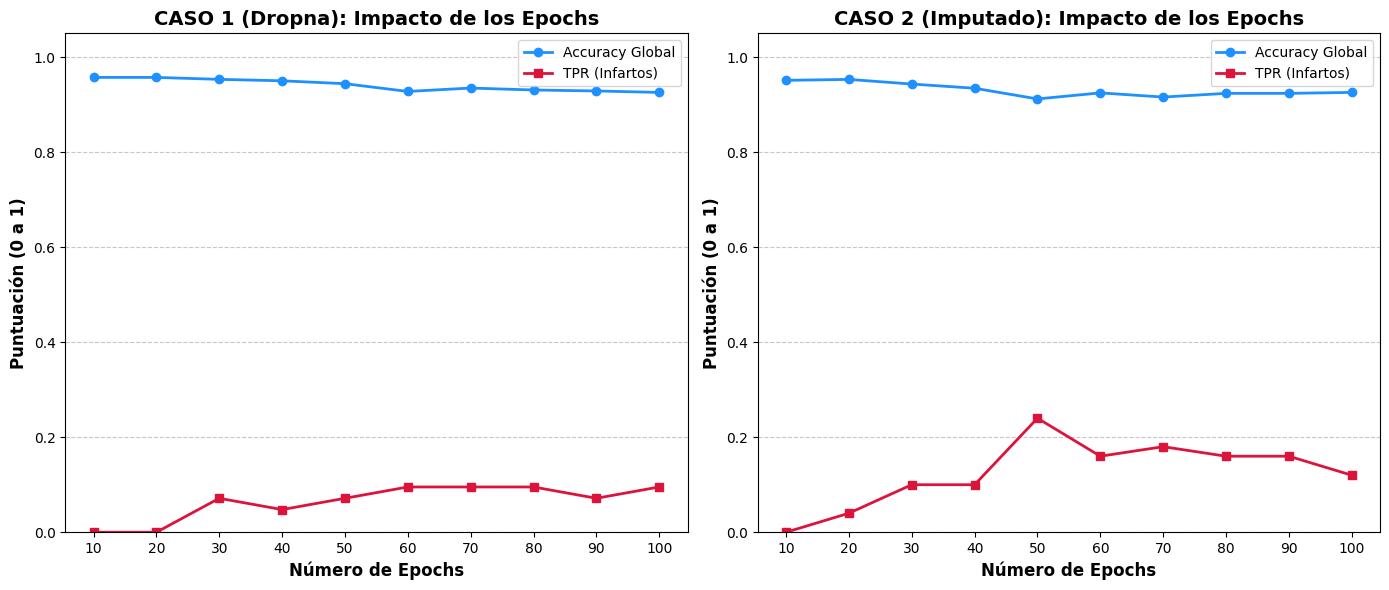

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score, accuracy_score

# 1. Definimos los epochs (iteraciones) a probar
epochs_lista = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def evaluar_epochs(X_train, y_train, X_test, y_test, nombre_caso):
    print(f"==================================================")
    print(f" EVALUANDO EPOCHS - {nombre_caso}")
    print(f"==================================================\n")

    resultados_acc = []
    resultados_tpr = []

    for epochs in epochs_lista:
        print(f"Entrenando con {epochs} Epochs...")
        # Usamos la arquitectura de 3 capas (64, 128, 128)
        mlp = MLPClassifier(hidden_layer_sizes=(64, 128, 128), activation='relu',
                            solver='adam', max_iter=epochs, random_state=42)

        # Atrapamos las advertencias si el modelo no converge rápido
        import warnings
        from sklearn.exceptions import ConvergenceWarning
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            mlp.fit(X_train, y_train)

        y_pred = mlp.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        tpr = recall_score(y_test, y_pred) # Recall de infartos

        resultados_acc.append(acc)
        resultados_tpr.append(tpr)

        print(f"Epochs: {epochs:3d} | Accuracy: {acc:.3f} | TPR (Infartos): {tpr:.3f}")

    return resultados_acc, resultados_tpr

# 2. Ejecutamos para Caso 1 y Caso 2
acc_c1, tpr_c1 = evaluar_epochs(X_train_drop, y_train_drop, X_test_drop, y_test_drop, "CASO 1 (DROPNA)")
acc_c2, tpr_c2 = evaluar_epochs(X_train_imp, y_train_imp, X_test_imp, y_test_imp, "CASO 2 (IMPUTADO)")

# 3. Gráfica comparativa visual
plt.figure(figsize=(14, 6))

# Gráfica Caso 1 (Dropna)
plt.subplot(1, 2, 1)
plt.plot(epochs_lista, acc_c1, label='Accuracy Global', marker='o', color='dodgerblue', linewidth=2)
plt.plot(epochs_lista, tpr_c1, label='TPR (Infartos)', marker='s', color='crimson', linewidth=2)
plt.title('CASO 1 (Dropna): Impacto de los Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Número de Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Puntuación (0 a 1)', fontsize=12, fontweight='bold')
plt.xticks(epochs_lista)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfica Caso 2 (Imputado)
plt.subplot(1, 2, 2)
plt.plot(epochs_lista, acc_c2, label='Accuracy Global', marker='o', color='dodgerblue', linewidth=2)
plt.plot(epochs_lista, tpr_c2, label='TPR (Infartos)', marker='s', color='crimson', linewidth=2)
plt.title('CASO 2 (Imputado): Impacto de los Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Número de Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Puntuación (0 a 1)', fontsize=12, fontweight='bold')
plt.xticks(epochs_lista)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Entrenando la comparativa final de todos los modelos (esto puede tardar unos minutos)...


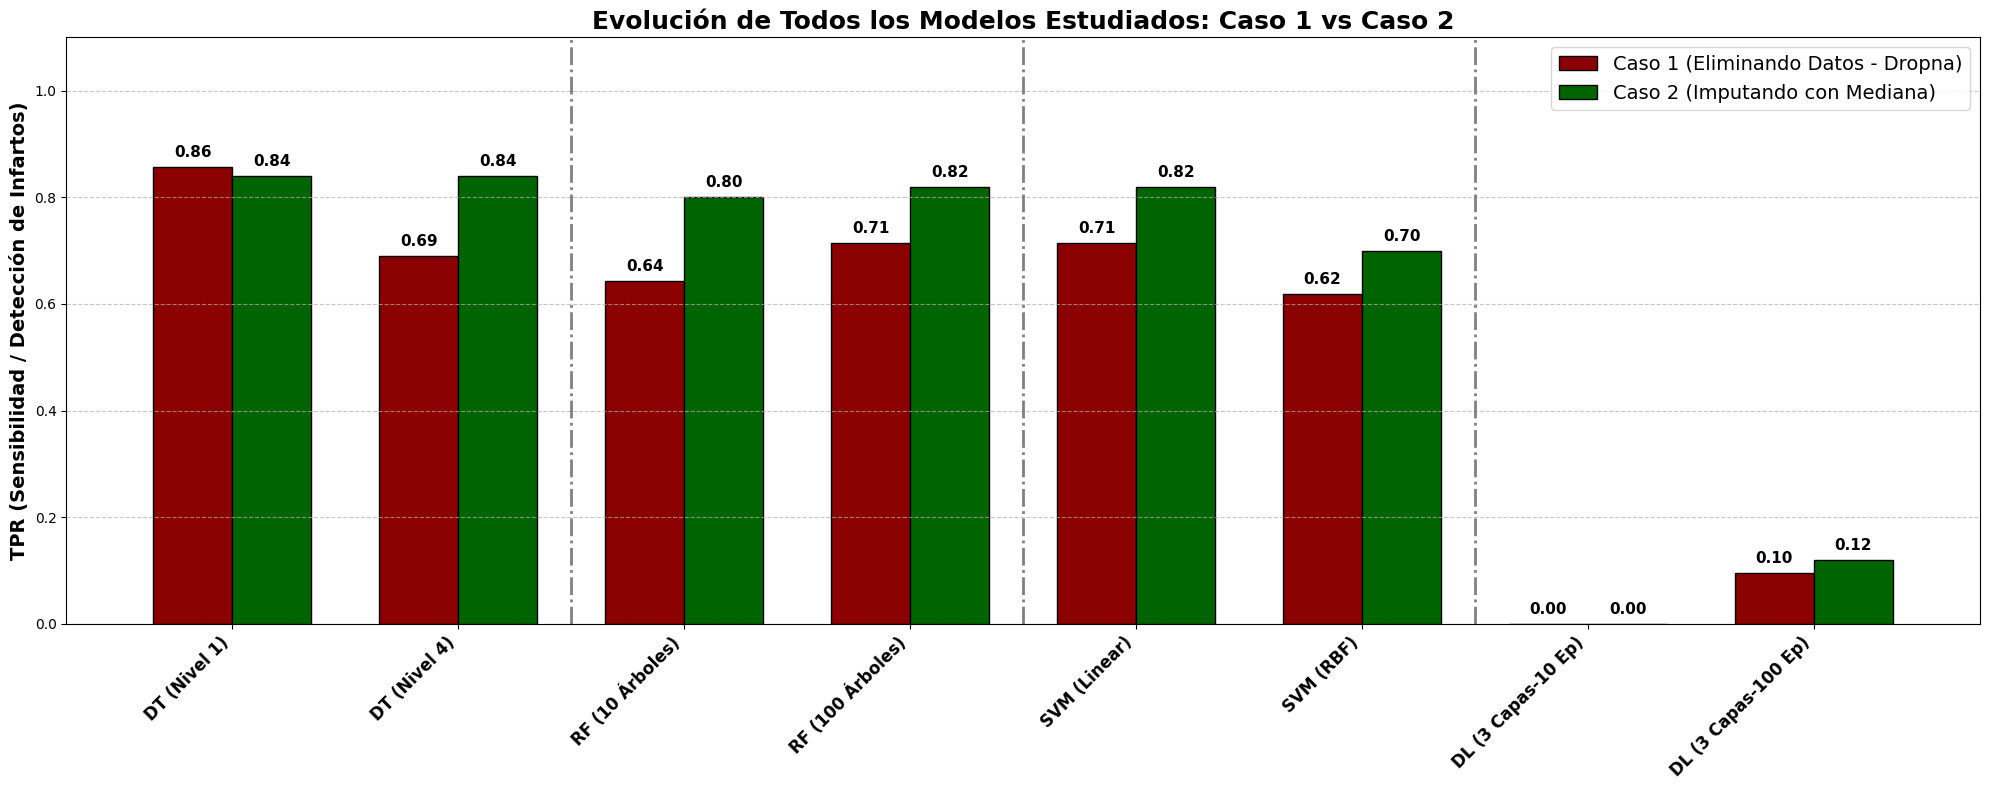

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignoramos warnings de convergencia del MLP para una consola limpia
warnings.simplefilter("ignore", category=ConvergenceWarning)

# ========================================================
# 1. DICCIONARIO DE MODELOS CON LOS CAMBIOS ESTUDIADOS
# ========================================================
modelos = {
    # Árboles de Decisión (El Underfitting vs El Punto Óptimo)
    "DT (Nivel 1)": DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42),
    "DT (Nivel 4)": DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),

    # Random Forest (La Estabilidad de la multitud)
    "RF (10 Árboles)": RandomForestClassifier(n_estimators=10, max_depth=4, class_weight='balanced', random_state=42),
    "RF (100 Árboles)": RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced', random_state=42),

    # SVM (La Geometría Espacial)
    "SVM (Linear)": SVC(kernel='linear', class_weight='balanced', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', random_state=42),

    # Deep Learning (El Problema del Desbalanceo y los Epochs)
    # Usamos 3 capas como estándar y variamos los Epochs
    "DL (3 Capas-10 Ep)": MLPClassifier(hidden_layer_sizes=(64, 128, 128), max_iter=10, random_state=42),
    "DL (3 Capas-100 Ep)": MLPClassifier(hidden_layer_sizes=(64, 128, 128), max_iter=100, random_state=42)
}

tpr_caso1 = []
tpr_caso2 = []
nombres_modelos = list(modelos.keys())

print("Entrenando la comparativa final de todos los modelos (esto puede tardar unos minutos)...")

# ========================================================
# 2. ENTRENAMIENTO Y EXTRACCIÓN DEL TPR (RECALL)
# ========================================================
for nombre, modelo in modelos.items():
    # Evaluación Caso 1 (Dropna)
    modelo.fit(X_train_drop, y_train_drop)
    y_pred_c1 = modelo.predict(X_test_drop)
    tpr_caso1.append(recall_score(y_test_drop, y_pred_c1))

    # Evaluación Caso 2 (Imputado)
    modelo.fit(X_train_imp, y_train_imp)
    y_pred_c2 = modelo.predict(X_test_imp)
    tpr_caso2.append(recall_score(y_test_imp, y_pred_c2))

# ========================================================
# 3. CREACIÓN DEL MEGA GRÁFICO COMPARATIVO
# ========================================================
x = np.arange(len(nombres_modelos))
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(20, 8))

# Barras para Caso 1 y Caso 2
rects1 = ax.bar(x - width/2, tpr_caso1, width, label='Caso 1 (Eliminando Datos - Dropna)', color='darkred', edgecolor='black')
rects2 = ax.bar(x + width/2, tpr_caso2, width, label='Caso 2 (Imputando con Mediana)', color='darkgreen', edgecolor='black')

# Personalización del gráfico
ax.set_ylabel('TPR (Sensibilidad / Detección de Infartos)', fontsize=14, fontweight='bold')
ax.set_title('Evolución de Todos los Modelos Estudiados: Caso 1 vs Caso 2', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nombres_modelos, rotation=45, ha="right", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Separadores visuales por familia de modelo
plt.axvline(x=1.5, color='gray', linestyle='-.', linewidth=2)
plt.axvline(x=3.5, color='gray', linestyle='-.', linewidth=2)
plt.axvline(x=5.5, color='gray', linestyle='-.', linewidth=2)

# Función para poner el número encima de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()